# Covid-19 (Oct-2019 → Dec-2021) on the Evergreen_v5 narrative panel: attention post-processing

Companion to `evergreen_tax_gfc_analysis.ipynb`: same data, same stages 1–5, applied to the
Covid window **2019-10-01 → 2021-12-01**. Reads the production `narrative_daily` artifact scored
against the registered **Evergreen_v5** taxonomy (R2, headline paraphrases, max pooling,
q = 0.99, point-in-time tau_asof). Read-only on the datalake; writes nothing.

**Raw signal θ.** θ_{d,n} = ATTENTION = TOTAL_SCORE / N_HEADLINES (share of day *d*'s headline
flow attributed to narrative *n*; ≥ 0; the poles of a bipolar narrative are separate series).

**Post-processing (stages 1–5, causal / point-in-time), identical to the GFC notebook:**

| # | stage | definition |
|---|---|---|
| 1 | deseasonalise | θ̃ = θ − s, s = **prior-years-only** mean of the ISO-week-of-year mean (expanding by default; `SEASONAL_YEARS` = trailing-window variant used as a robustness check) |
| 2 | weekly | Mon–Fri mean of θ̃, stamped on the Friday |
| 3 | change | Δθ_t = θ̄_t − θ̄_{t−1} |
| 4 | horizons | Δθ^{(h)} = backward rolling mean of Δθ over *h* weeks; short 1–12w, long 12–52w |
| 5 | composite | C = mean_{h∈H} Δθ^{(h)} / σ^{(h)}_t, H = {12, 26, 52}, σ = cross-sectional std (ddof 0), numerator **not demeaned** |

**What the GFC study taught, and what changes here**

| GFC finding | response in this notebook |
|---|---|
| Attention measures the *topic*, not the direction: mirror poles (e.g. `bank-balance-sheet-repair`) lit up with the stress poles, so the must-not-fire placebo failed | (a) a **topic-level** run of stages 1–5 on dimension attention (poles summed); (b) the "mirror poles" battery is reported as a **leakage diagnostic**, not a placebo; (c) the placebo battery is **topic-orthogonal** |
| H = {12, 26, 52} under-detects abrupt shocks (BNP peaked at 4w) | a **short composite** C_S over {1, 4, 12} is reported next to C (Covid is the most abrupt shock in the sample) |
| Stage 1 on the expanding pre-2007 feed leaves earnings seasonality | robustness run with a **trailing 5-year** seasonal mean, plus the no-stage-1 run |
| Permutation test ignores serial correlation | a **block-bootstrap** baseline band (8-week blocks) is added to the battery event table |
| The not-demeaned cross-sectional mean is ~0 for attention (shares sum to a constant) | shown, but not interpreted as a signal |

Return branches (6a / 6b) are out of scope: this notebook analyses the attention signal itself.

In [1]:
import os
from datetime import date, timedelta

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm
from dotenv import find_dotenv, load_dotenv

from datalake import DatalakeIndex

load_dotenv(find_dotenv(usecwd=True))
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_width_chars(220); pl.Config.set_fmt_str_lengths(60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True})

# ---- data -----------------------------------------------------------------------------
TAXONOMY = "Evergreen_v5"
NARRATIVE_DAILY_ID = None        # None = most recent narrative_daily of TAXONOMY (partial allowed)
KEY = "narrative_key"            # scoped reservoir|dimension|narrative(|pole) id

# ---- post-processing ------------------------------------------------------------------
MIN_PRIOR_YEARS = 1              # stage 1: seasonal mean needs >= this many prior years
SEASONAL_YEARS = None            # None = expanding (spec); int = trailing window of prior years
SEASONAL_YEARS_ROBUST = 5        # robustness variant
SHORT_H = (1, 2, 4, 8, 12)
LONG_H = (12, 26, 52)
COMPOSITE_H = (12, 26, 52)       # stage 5 (spec)
COMPOSITE_SHORT_H = (1, 4, 12)   # abrupt-shock companion
ALL_H = tuple(sorted(set(SHORT_H) | set(LONG_H)))

# ---- study windows --------------------------------------------------------------------
WINDOW = (date(2019, 10, 1), date(2021, 12, 1))
VIEW = WINDOW
BASELINE = (date(2017, 10, 1), date(2019, 9, 30))   # 2 pre-Covid years, same feed regime
ONSET_THRESHOLD = 1.0
N_PERM = 20_000
N_BOOT = 2_000
BLOCK_WEEKS = 8
RNG = np.random.default_rng(0)

EVENTS = {
    "WHO notified (Wuhan)": date(2019, 12, 31),
    "Wuhan lockdown": date(2020, 1, 23),
    "Italy outbreak": date(2020, 2, 24),
    "Fed emergency cut": date(2020, 3, 3),
    "WHO pandemic": date(2020, 3, 11),
    "Fed to zero + QE": date(2020, 3, 15),
    "Unlimited QE / trough": date(2020, 3, 23),
    "CARES Act": date(2020, 3, 27),
    "Negative WTI": date(2020, 4, 20),
    "Pfizer efficacy": date(2020, 11, 9),
    "First vaccination (UK)": date(2020, 12, 8),
    "GameStop squeeze": date(2021, 1, 27),
    "American Rescue Plan": date(2021, 3, 11),
    "CPI surprise (Apr print)": date(2021, 5, 12),
    "Omicron named": date(2021, 11, 26),
}
KEY_EVENTS = ("Wuhan lockdown", "WHO pandemic", "Unlimited QE / trough", "Pfizer efficacy",
              "CPI surprise (Apr print)")

BATTERIES = {
    "health shock": ["pandemic-and-epidemic-outbreak", "health-fear-and-contagion-salience",
                     "public-health-deterioration"],
    "lockdown / state control": ["state-security-imposition", "state-direction-expansion",
                                 "price-and-market-control-imposition"],
    "market crash": ["fear-gauge-spike", "turbulent-market-read", "risk-off-flight", "flight-to-safety-demand",
                     "capitulation-crash-narrative", "market-liquidity-breakdown",
                     "trading-halt-and-circuit-breaker"],
    "dash for cash / funding": ["funding-squeeze", "cross-border-dollar-funding-stress",
                                "repo-and-money-market-dislocation", "money-market-fund-run",
                                "swap-spread-and-basis-dislocation", "auction-tail-and-weak-demand",
                                "non-bank-deleveraging"],
    "monetary response": ["rate-easing-cycle", "balance-sheet-expansion", "liquidity-facility-as-policy",
                          "swap-line-activation", "negative-and-lower-bound-regime", "global-liquidity-easing",
                          "dovish-guidance-shift"],
    "fiscal response": ["fiscal-expansion-impulse", "fiscal-easing-decision", "automatic-stabiliser-swing",
                        "budget-passage-salience"],
    "real contraction": ["business-cycle-contraction", "hard-landing", "labour-market-slackening",
                         "demand-retrenchment", "aggregate-earnings-recession", "guidance-cut", "dividend-cut"],
    "corporate distress": ["bankruptcy-and-restructuring", "credit-deterioration", "rating-downgrade",
                           "default-and-covenant-breach", "refinancing-and-maturity-wall", "default-wave-salience"],
    "oil / demand collapse": ["demand-destruction", "demand-driven-price-collapse", "supply-glut",
                              "curve-contango", "producer-group-output-shift"],
    "supply chain": ["supply-chain-disruption", "logistics-and-transport-break", "supply-chain-stress-attention",
                     "product-shortage-and-outage", "staffing-shortage", "input-supply-shock-attention"],
    "vaccine / health recovery": ["public-health-improvement", "product-approval", "approval-decision-attention",
                                  "feasibility-demonstration"],
    "reopening / recovery": ["control-relaxation", "recovery-and-re-acceleration", "operations-resumption",
                             "business-cycle-expansion", "capex-upswing"],
    "reflation / inflation": ["price-level-change-reflation", "accelerating-inflation", "input-cost-pass-through",
                              "wage-growth-pressure", "labour-market-tightening", "input-cost-squeeze"],
    "retail speculation": ["retail-coordination-positioning", "short-squeeze-mechanics",
                           "novel-instrument-speculation-hype", "theme-hype-build", "bubble-framing"],
    "MIRROR POLES (leakage)": ["consumption-boom", "benign-credit-environment", "calm-market-read",
                               "complacency-read", "risk-on-appetite", "credit-boom", "housing-boom"],
    "PLACEBO (orthogonal)": ["harvest-and-yield-outturn", "resource-discovery-and-exploration",
                             "benchmark-integrity-breach", "standards-war", "allowance-cap-tightening",
                             "allowance-cap-loosening", "demographic-vitality-rise", "executive-compensation-dispute",
                             "spin-off-and-separation", "dominant-design-emergence"],
}
PLACEBO = "PLACEBO (orthogonal)"
MIRROR = "MIRROR POLES (leakage)"
DIAGNOSTIC = (PLACEBO, MIRROR)
SHOWCASE = "pandemic-and-epidemic-outbreak"

# topic (dimension) batteries for the direction-free view: reservoir|dimension
TOPIC_BATTERIES = {
    "public health": ["society|public-health-condition"],
    "market volatility": ["market-perception|expected-volatility-read", "market-perception|realized-volatility-read",
                          "market-perception|expressed-risk-appetite"],
    "funding & plumbing": ["financial-system|funding-and-liquidity-condition",
                           "financial-system|yield-and-spread-plumbing",
                           "financial-system|market-functioning-and-microstructure"],
    "monetary policy": ["monetary|policy-rate-stance", "monetary|balance-sheet-policy",
                        "monetary|cross-border-monetary-conditions"],
    "fiscal": ["macroeconomic|fiscal-stance-impulse", "political|fiscal-tax-policy-direction"],
    "output & labour": ["macroeconomic|aggregate-output-and-cycle", "macroeconomic|labour-market-slack",
                        "macroeconomic|aggregate-demand-condition"],
    "supply chain": ["industry|supply-and-operations-condition", "commodities|physical-supply-disruption",
                     "industry|sector-input-and-cost-condition"],
    "prices": ["macroeconomic|price-level-change"],
    "state control": ["political|domestic-order-and-state-security", "political|state-control-of-economic-activity"],
    "PLACEBO (orthogonal)": ["technology|standardisation", "society|demographic-condition",
                             "political|policy-created-instrument-regime"],
}


def shade_events(ax, which=KEY_EVENTS, labels=True):
    ymax = ax.get_ylim()[1]
    for name in which:
        d = EVENTS[name]
        ax.axvline(d, color="0.35", lw=0.8, ls="--", zorder=0)
        if labels:
            ax.text(d, ymax, f" {name}", rotation=90, va="top", ha="right", fontsize=7, color="0.3")


def date_axis(ax, lo=VIEW[0], hi=VIEW[1]):
    ax.set_xlim(lo, hi)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

## 1. Data

The full history is loaded (stage 1 needs every prior year). The artifact may still be `partial`;
the notebook checks that the panel covers the whole Covid window and warns otherwise.

In [2]:
dl = DatalakeIndex(os.environ["DATALAKE_ROOT"], create=False)
if NARRATIVE_DAILY_ID is not None:
    ART = dl.get(NARRATIVE_DAILY_ID)
else:
    cands = [a for a in dl.list("narrative_daily", include_partial=True)
             if a.meta.hyperparams.get("taxonomy_name") == TAXONOMY and not a.deprecated]
    if not cands:
        raise LookupError(f"no narrative_daily artifact for taxonomy {TAXONOMY!r}")
    ART = cands[0]
hp = ART.meta.hyperparams
print(ART.artifact_id, "| partial:", ART.partial)
print({k: hp.get(k) for k in ("taxonomy_name", "taxonomy_artifact_id", "mode", "pooling",
                              "paraphrase_style", "q", "split", "window", "config_id")})
FILES = sorted(ART.path.glob("[12][0-9][0-9][0-9]-[01][0-9].parquet"))
print(f"{len(FILES)} month files: {FILES[0].stem} .. {FILES[-1].stem}")

narrative_daily__v2.2.0__params0a029753__20260927 | partial: False
{'taxonomy_name': 'Evergreen_v5', 'taxonomy_artifact_id': 'narrative_taxonomy__v2.1.0__paramsbf25ede9__20260923', 'mode': 'r2', 'pooling': 'max', 'paraphrase_style': 'headline', 'q': 0.99, 'split': 'none', 'window': '5Y', 'config_id': '9de874ad4aaa9d3e'}
309 month files: 2000-04 .. 2025-12


In [3]:
def load_attention(files) -> pl.DataFrame:
    # daily (DATE x narrative_key) attention; THETA is null only when the day has no headlines
    return (
        pl.scan_parquet([str(f) for f in files])
        .filter(pl.col("SENTIMENT") == "all")
        .select("DATE", "reservoir", "dimension", "narrative", "pole", KEY,
                "SUPPORT", "TOTAL_SCORE", "N_HEADLINES")
        .with_columns(
            pl.when(pl.col("N_HEADLINES") > 0)
            .then(pl.col("TOTAL_SCORE").fill_null(0.0) / pl.col("N_HEADLINES"))
            .otherwise(None).alias("THETA"))
        .sort(KEY, "DATE")
        .collect()
    )


daily = load_attention(FILES)
NARR = daily.select("reservoir", "dimension", "narrative", "pole", KEY).unique(KEY).sort(KEY)
last_day = daily["DATE"].max()
print(f"{daily.height:,} rows | {daily['DATE'].n_unique():,} days | {NARR.height} narrative keys | "
      f"{daily['DATE'].min()} .. {last_day}")
assert daily.group_by("DATE", KEY).len().filter(pl.col("len") > 1).height == 0
if last_day < WINDOW[1]:
    print(f"WARNING: panel ends {last_day}, before the window end {WINDOW[1]}: the tail of the "
          f"window is missing (scoring job still running?)")
    VIEW = (WINDOW[0], last_day)

3,941,114 rows | 9,406 days | 419 narrative keys | 2000-04-01 .. 2025-12-31


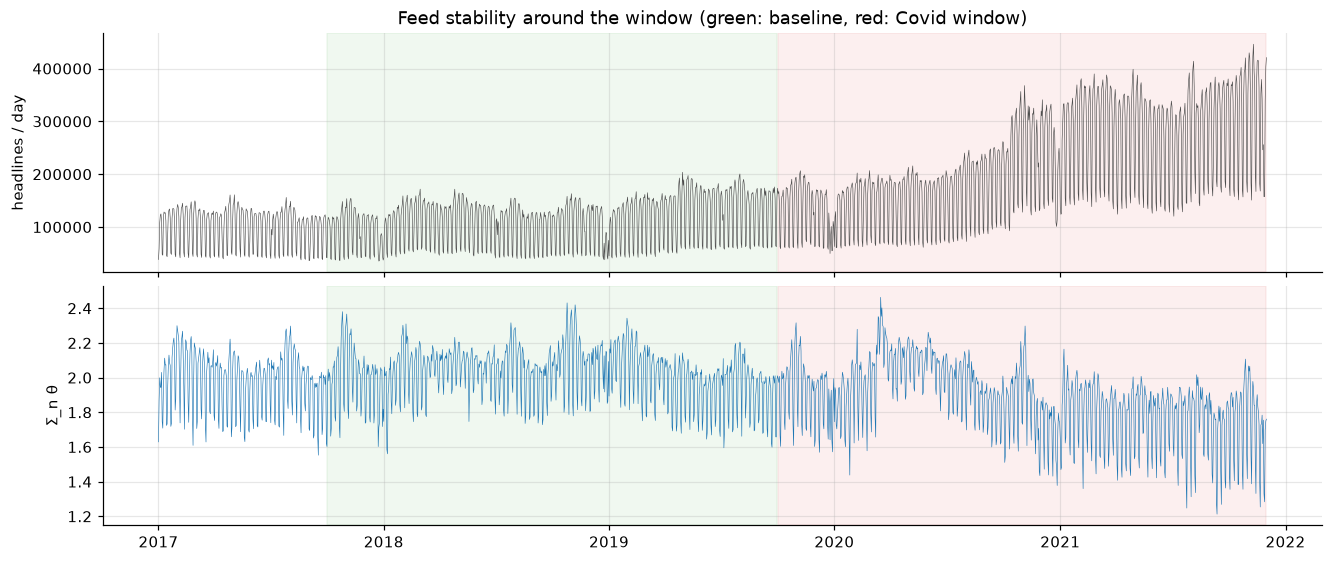

Y,headlines/day,mean Σθ
i32,f64,f64
2017,98757.0,1.985
2018,106540.0,2.053
2019,128253.0,1.968
2020,178047.0,1.952
2021,285374.0,1.767


In [4]:
flow = (daily.filter(pl.col("DATE").is_between(date(2017, 1, 1), VIEW[1]))
        .group_by("DATE").agg(pl.col("N_HEADLINES").first(), pl.col("THETA").sum().alias("SUM_THETA"))
        .sort("DATE"))
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(flow["DATE"], flow["N_HEADLINES"], lw=0.4, color="0.3"); axes[0].set_ylabel("headlines / day")
axes[1].plot(flow["DATE"], flow["SUM_THETA"], lw=0.4, color="tab:blue"); axes[1].set_ylabel("Σ_n θ")
for ax in axes:
    ax.axvspan(*WINDOW, color="tab:red", alpha=0.07); ax.axvspan(*BASELINE, color="tab:green", alpha=0.07)
axes[0].set_title("Feed stability around the window (green: baseline, red: Covid window)")
plt.show()
yr = (flow.with_columns(pl.col("DATE").dt.year().alias("Y")).group_by("Y")
      .agg(pl.col("N_HEADLINES").mean().round(0).alias("headlines/day"),
           pl.col("SUM_THETA").mean().round(3).alias("mean Σθ")).sort("Y"))
yr

## 2. Post-processing pipeline (stages 1–5)

Same functions as the GFC notebook, with two additions: a trailing-window option for the
stage-1 seasonal mean, and a second (short) composite. Everything is per `narrative_key` and
uses only information available at the Friday of week *t*.

In [5]:
def deseasonalise(daily: pl.DataFrame, min_prior_years: int = MIN_PRIOR_YEARS,
                  seasonal_years: int | None = SEASONAL_YEARS) -> pl.DataFrame:
    # stage 1: subtract the prior-years-only week-of-year mean (expanding, or trailing N years)
    d = daily.with_columns(pl.col("DATE").dt.iso_year().alias("YEAR"),
                           pl.col("DATE").dt.week().clip(1, 52).alias("WOY"))
    yw = (d.group_by(KEY, "YEAR", "WOY").agg(pl.col("THETA").mean().alias("YW_MEAN"))
          .sort(KEY, "WOY", "YEAR")
          .with_columns(pl.col("YW_MEAN").is_not_null().cast(pl.Int32).alias("_has"),
                        pl.col("YW_MEAN").fill_null(0.0).alias("_v")))
    if seasonal_years is None:
        yw = yw.with_columns(pl.col("_v").cum_sum().shift(1).over(KEY, "WOY").alias("_psum"),
                             pl.col("_has").cum_sum().shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
    else:
        n = int(seasonal_years)
        yw = yw.with_columns(
            pl.col("_v").rolling_sum(n, min_samples=1).shift(1).over(KEY, "WOY").alias("_psum"),
            pl.col("_has").rolling_sum(n, min_samples=1).shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
    yw = (yw.with_columns(pl.when(pl.col("N_PRIOR_YEARS") >= min_prior_years)
                          .then(pl.col("_psum") / pl.col("N_PRIOR_YEARS")).otherwise(None).alias("SEAS"))
          .select(KEY, "YEAR", "WOY", "SEAS", "N_PRIOR_YEARS"))
    return (d.join(yw, on=[KEY, "YEAR", "WOY"], how="left")
            .with_columns((pl.col("THETA") - pl.col("SEAS")).alias("THETA_DS")))


def weekly(d: pl.DataFrame) -> pl.DataFrame:
    # stage 2: Mon-Fri mean, stamped on the Friday, on a complete (week x key) grid
    w = (d.filter(pl.col("DATE").dt.weekday() <= 5)
         .with_columns((pl.col("DATE").dt.truncate("1w") + timedelta(days=4)).alias("WEEK"))
         .group_by(KEY, "WEEK")
         .agg(pl.col("THETA_DS").mean().alias("THETA_W"), pl.col("THETA").mean().alias("THETA_RAW_W"),
              pl.col("THETA").count().alias("N_DAYS")))
    grid = pl.DataFrame({"WEEK": pl.date_range(w["WEEK"].min(), w["WEEK"].max(), "1w", eager=True)}).join(
        w.select(KEY).unique(), how="cross")
    return grid.join(w, on=[KEY, "WEEK"], how="left").sort(KEY, "WEEK")


def changes_and_horizons(w: pl.DataFrame, value: str = "THETA_W", horizons=ALL_H) -> pl.DataFrame:
    # stage 3 (first difference) + stage 4 (backward rolling mean over h weeks, full windows only)
    w = w.with_columns(pl.col(value).diff().over(KEY).alias("DTHETA"))
    return w.with_columns([pl.col("DTHETA").rolling_mean(h, min_samples=h).over(KEY).alias(f"D{h}")
                           for h in horizons])


def composite(w: pl.DataFrame, all_h=ALL_H) -> pl.DataFrame:
    # stage 5: each horizon / its own cross-sectional std (ddof=0, NOT demeaned), averaged over H
    w = w.with_columns([(pl.col(f"D{h}") / pl.col(f"D{h}").std(ddof=0).over("WEEK")).alias(f"Z{h}")
                        for h in all_h])

    def avg(hs, name):
        z = [pl.col(f"Z{h}") for h in hs]
        ok = pl.all_horizontal([c.is_not_null() & c.is_finite() for c in z])
        return pl.when(ok).then(pl.sum_horizontal(z) / len(z)).otherwise(None).alias(name)

    return w.with_columns(avg(COMPOSITE_H, "COMPOSITE"), avg(COMPOSITE_SHORT_H, "COMPOSITE_S"))


def post_process(daily: pl.DataFrame, deseason: bool = True, seasonal_years=SEASONAL_YEARS) -> pl.DataFrame:
    d = (deseasonalise(daily, seasonal_years=seasonal_years) if deseason
         else daily.with_columns(pl.col("THETA").alias("THETA_DS")))
    return composite(changes_and_horizons(weekly(d)))


daily_ds = deseasonalise(daily)
panel = composite(changes_and_horizons(weekly(daily_ds)))
print(f"{panel.height:,} (week x narrative) rows | weeks {panel['WEEK'].min()} .. {panel['WEEK'].max()}")
cs = panel.filter(pl.col("COMPOSITE").is_not_null())
for h in COMPOSITE_H:
    s = cs.group_by("WEEK").agg(pl.col(f"Z{h}").std(ddof=0))[f"Z{h}"]
    assert np.allclose(s.to_numpy(), 1.0, atol=1e-6), h
print("σ^(h) normalisation holds; window weeks with a composite:",
      cs.filter(pl.col("WEEK").is_between(*VIEW))["WEEK"].n_unique())

563,136 (week x narrative) rows | weeks 2000-04-07 .. 2026-01-02
σ^(h) normalisation holds; window weeks with a composite: 113


### 2.1 Stage-by-stage walk-through on the pandemic narrative

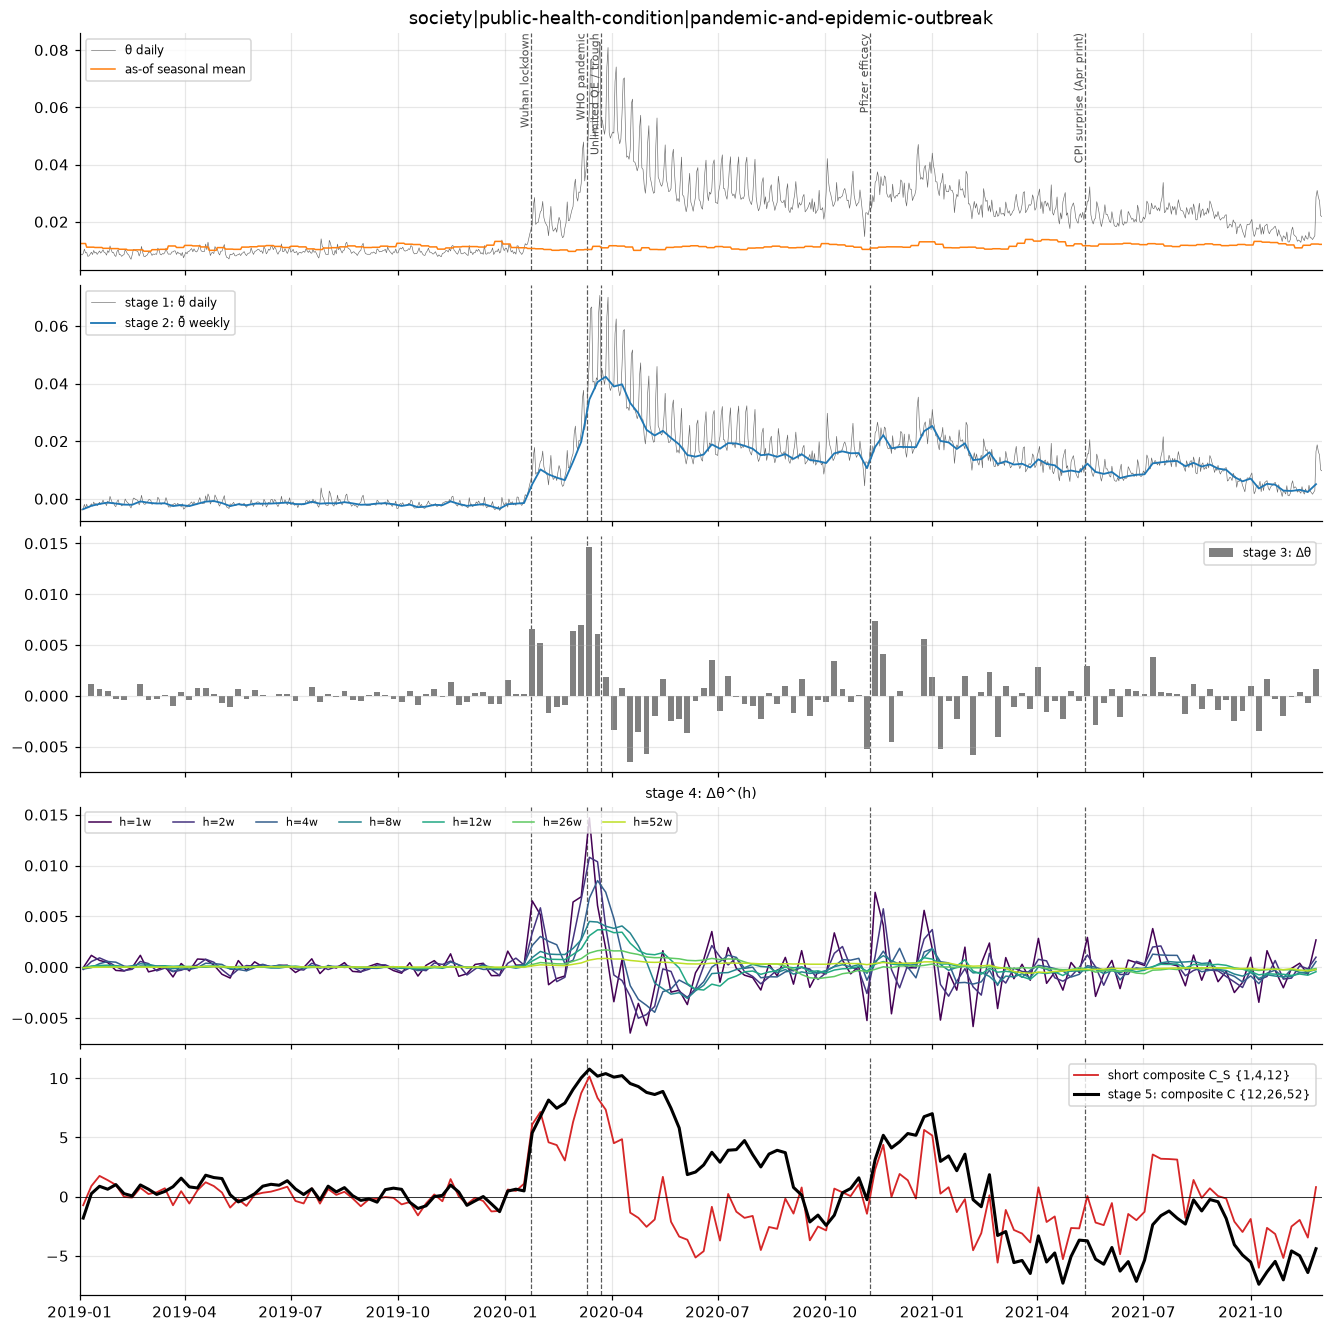

In [6]:
k0 = NARR.filter(pl.col("narrative") == SHOWCASE)[KEY].to_list()[0]
lo = date(2019, 1, 1)
dd = daily_ds.filter((pl.col(KEY) == k0) & pl.col("DATE").is_between(lo, VIEW[1]))
pp = panel.filter((pl.col(KEY) == k0) & pl.col("WEEK").is_between(lo, VIEW[1]))

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(dd["DATE"], dd["THETA"], lw=0.4, color="0.4", label="θ daily")
axes[0].plot(dd["DATE"], dd["SEAS"], lw=1.0, color="tab:orange", label="as-of seasonal mean")
axes[0].set_title(k0); axes[0].legend(loc="upper left", fontsize=8)
axes[1].plot(dd["DATE"], dd["THETA_DS"], lw=0.4, color="0.4", label="stage 1: θ̃ daily")
axes[1].plot(pp["WEEK"], pp["THETA_W"], lw=1.2, color="tab:blue", label="stage 2: θ̄ weekly")
axes[1].legend(loc="upper left", fontsize=8)
axes[2].bar(pp["WEEK"], pp["DTHETA"], width=5, color="0.5", label="stage 3: Δθ"); axes[2].legend(fontsize=8)
for h, c in zip(ALL_H, plt.cm.viridis(np.linspace(0, 0.9, len(ALL_H)))):
    axes[3].plot(pp["WEEK"], pp[f"D{h}"], lw=1.0, color=c, label=f"h={h}w")
axes[3].set_title("stage 4: Δθ^(h)", fontsize=9); axes[3].legend(ncol=len(ALL_H), fontsize=7, loc="upper left")
axes[4].plot(pp["WEEK"], pp["COMPOSITE_S"], lw=1.2, color="tab:red", label="short composite C_S {1,4,12}")
axes[4].plot(pp["WEEK"], pp["COMPOSITE"], lw=2.0, color="k", label="stage 5: composite C {12,26,52}")
axes[4].axhline(0, color="k", lw=0.5); axes[4].legend(fontsize=8, loc="upper right")
for ax in axes:
    date_axis(ax, lo, VIEW[1]); shade_events(ax, labels=ax is axes[0])
plt.show()

## 3. Composite properties over the window

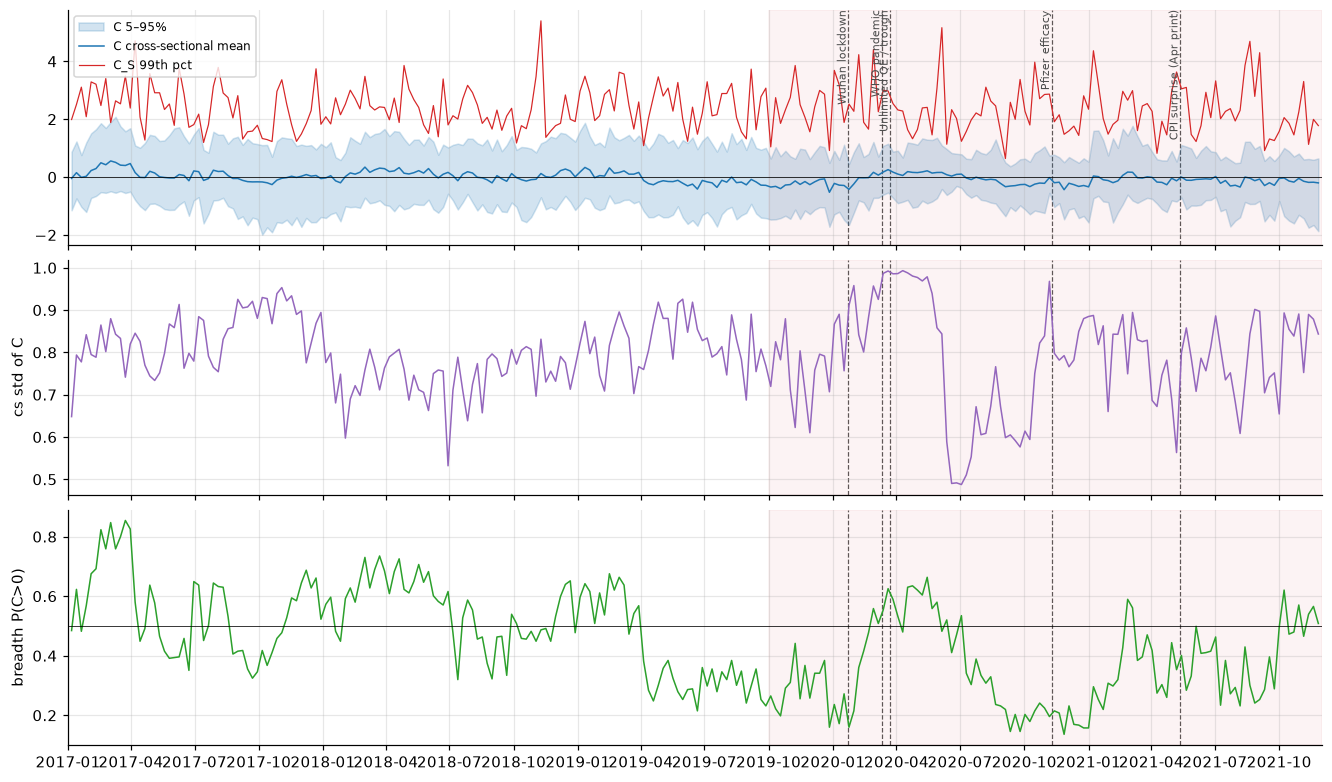

In [7]:
xs = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(date(2017, 1, 1), VIEW[1]))
      .group_by("WEEK")
      .agg(pl.col("COMPOSITE").mean().alias("MEAN"), pl.col("COMPOSITE").std(ddof=0).alias("STD"),
           (pl.col("COMPOSITE") > 0).mean().alias("BREADTH"),
           pl.col("COMPOSITE").quantile(0.95).alias("Q95"), pl.col("COMPOSITE").quantile(0.05).alias("Q05"),
           pl.col("COMPOSITE_S").quantile(0.99).alias("QS99"))
      .sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].fill_between(xs["WEEK"], xs["Q05"], xs["Q95"], color="tab:blue", alpha=0.2, label="C 5–95%")
axes[0].plot(xs["WEEK"], xs["MEAN"], color="tab:blue", lw=1, label="C cross-sectional mean")
axes[0].plot(xs["WEEK"], xs["QS99"], color="tab:red", lw=0.8, label="C_S 99th pct")
axes[0].axhline(0, color="k", lw=0.5); axes[0].legend(fontsize=8, loc="upper left")
axes[1].plot(xs["WEEK"], xs["STD"], color="tab:purple", lw=1); axes[1].set_ylabel("cs std of C")
axes[2].plot(xs["WEEK"], xs["BREADTH"], color="tab:green", lw=1); axes[2].axhline(0.5, color="k", lw=0.5)
axes[2].set_ylabel("breadth P(C>0)")
for ax in axes:
    date_axis(ax, date(2017, 1, 1), VIEW[1]); ax.axvspan(*WINDOW, color="tab:red", alpha=0.05)
    shade_events(ax, labels=ax is axes[0])
plt.show()

## 4. Predeclared Covid batteries

Battery composite = equal-weight mean of C (and of C_S) over the battery's narrative keys.
The two diagnostic batteries are drawn dotted/grey: **MIRROR POLES** are the opposite poles of
the Covid stress topics (expected to fire if attention leaks across poles; this is *not* a
placebo), **PLACEBO** is topic-orthogonal (should stay unremarkable).

In [8]:
name_to_keys = {n: g[KEY].to_list() for (n,), g in NARR.group_by("narrative")}
BKEYS = {}
for b, names in BATTERIES.items():
    missing = [n for n in names if n not in name_to_keys]
    if missing:
        print(f"[{b}] names not in the taxonomy: {missing}")
    BKEYS[b] = [k for n in names for k in name_to_keys.get(n, [])]
print({b: len(k) for b, k in BKEYS.items()})
blist = [b for b in BKEYS if BKEYS[b]]


def battery_frame(panel, col, bkeys):
    wide = panel.filter(pl.col(col).is_not_null()).pivot(on=KEY, index="WEEK", values=col).sort("WEEK")
    m = wide.drop("WEEK")
    return wide["WEEK"], m, pl.DataFrame({"WEEK": wide["WEEK"], **{
        b: np.nanmean(m.select([k for k in ks if k in m.columns]).to_numpy(), axis=1)
        for b, ks in bkeys.items() if ks}})


WEEKS, C, bat = battery_frame(panel, "COMPOSITE", BKEYS)
WEEKS_S, CS, bat_s = battery_frame(panel, "COMPOSITE_S", BKEYS)
base = bat.filter(pl.col("WEEK").is_between(*BASELINE))
batz = bat.with_columns([((pl.col(b) - base[b].mean()) / base[b].std()).alias(b) for b in blist])
v = bat.filter(pl.col("WEEK").is_between(*VIEW)); v_s = bat_s.filter(pl.col("WEEK").is_between(*VIEW))
print(f"baseline {BASELINE[0]} .. {BASELINE[1]}: {base.height} weeks")

{'health shock': 3, 'lockdown / state control': 3, 'market crash': 7, 'dash for cash / funding': 7, 'monetary response': 7, 'fiscal response': 4, 'real contraction': 7, 'corporate distress': 6, 'oil / demand collapse': 5, 'supply chain': 6, 'vaccine / health recovery': 4, 'reopening / recovery': 5, 'reflation / inflation': 6, 'retail speculation': 5, 'MIRROR POLES (leakage)': 7, 'PLACEBO (orthogonal)': 10}
baseline 2017-10-01 .. 2019-09-30: 104 weeks


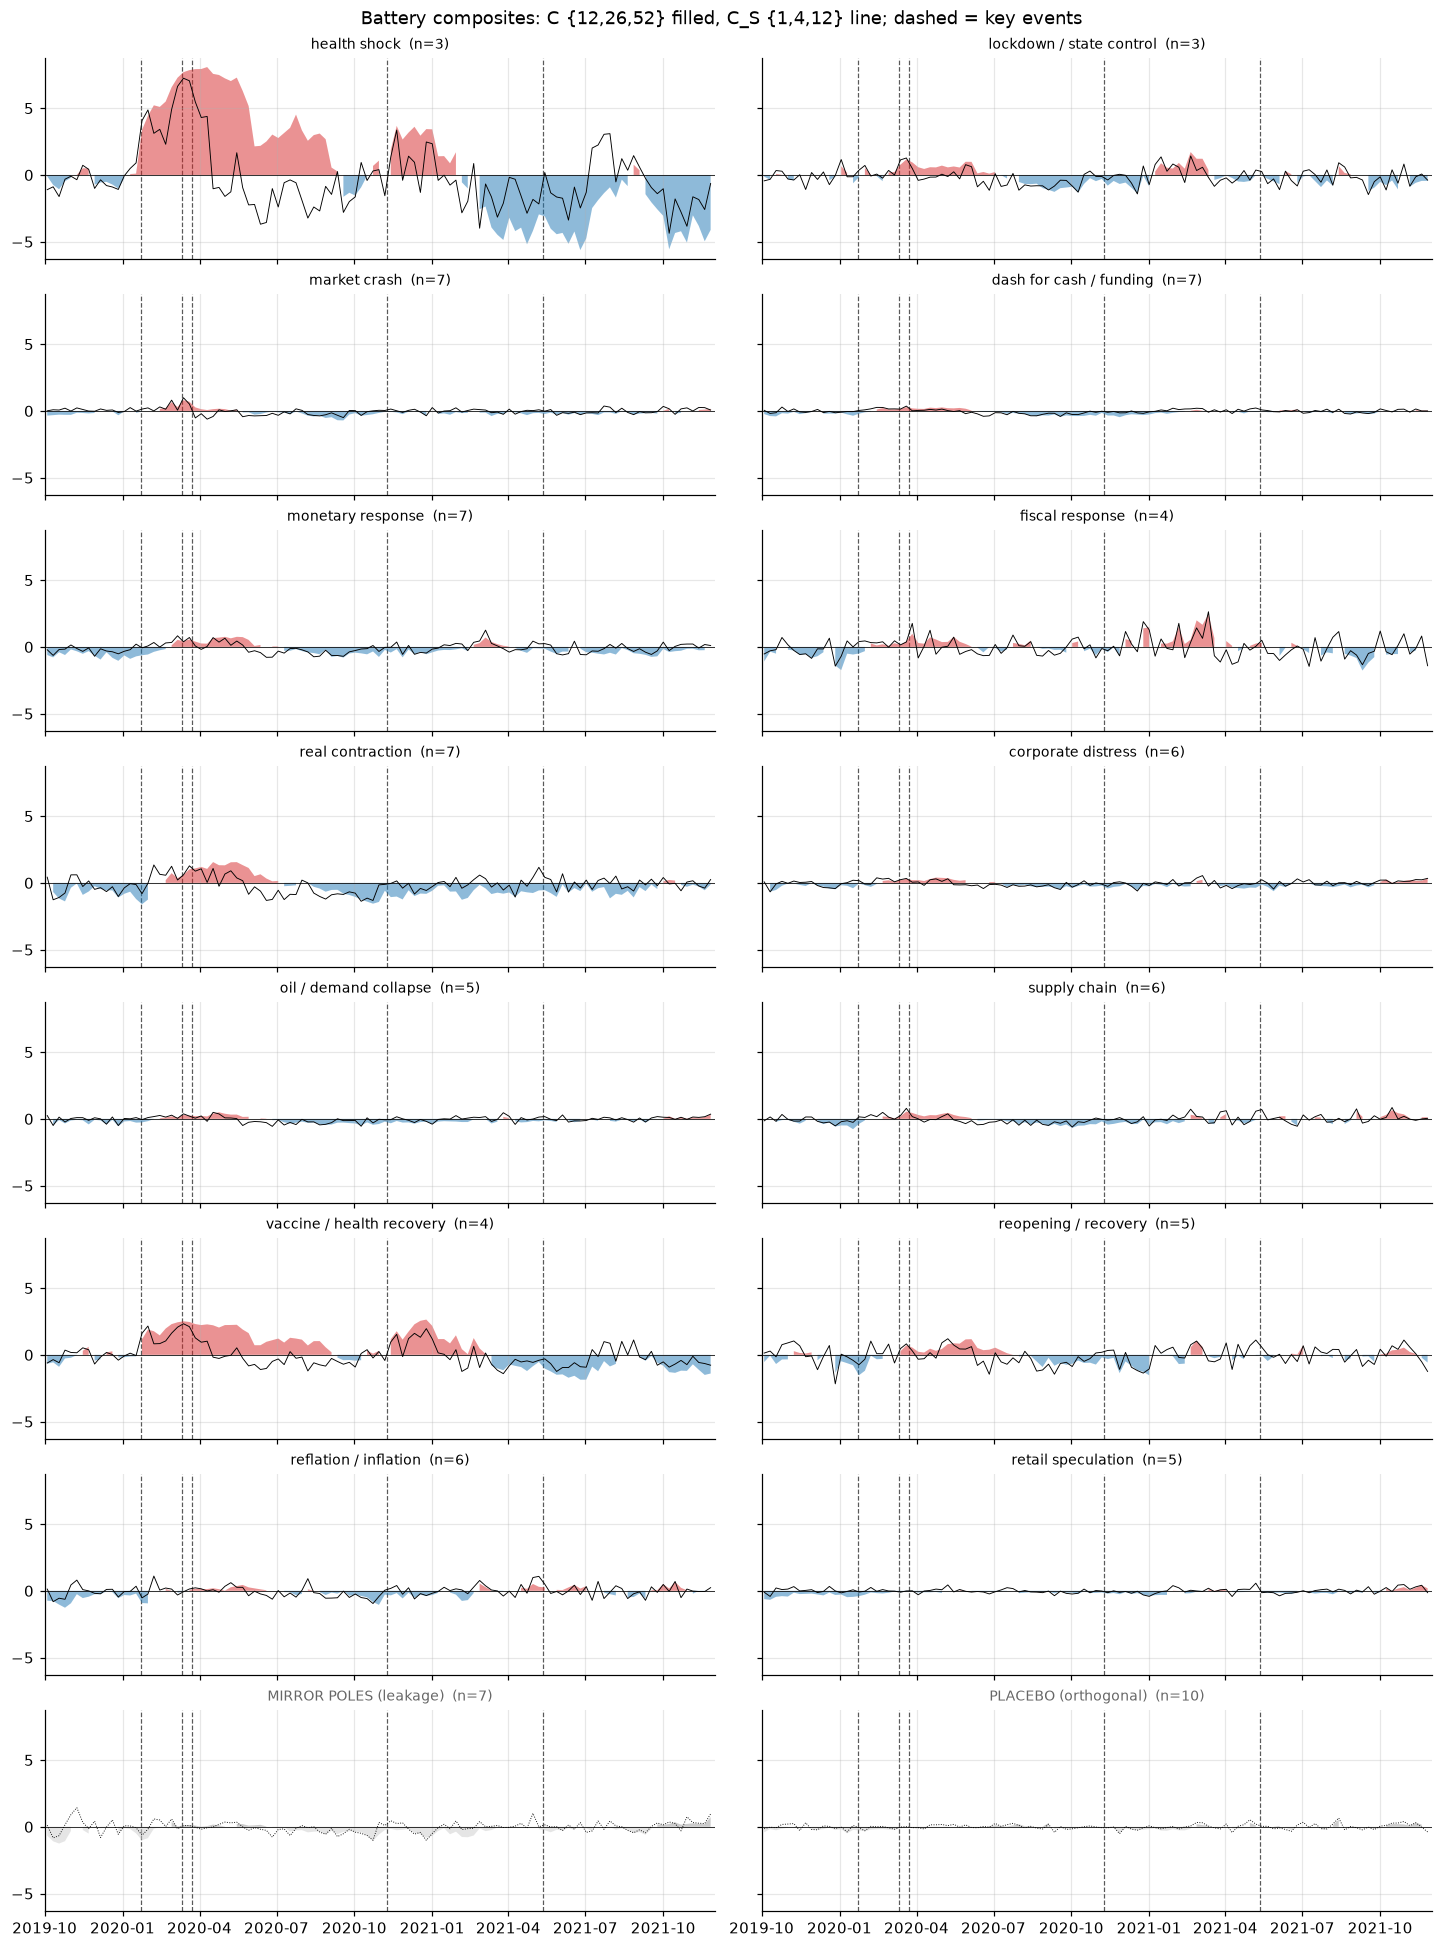

In [9]:
ncol = 2
nrow = int(np.ceil(len(blist) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.2 * nrow), sharex=True, sharey=True)
for ax, b in zip(axes.flat, blist):
    y = v[b].to_numpy()
    diag = b in DIAGNOSTIC
    ax.fill_between(v["WEEK"], 0, y, where=y > 0, color="0.6" if diag else "tab:red", alpha=0.5, lw=0)
    ax.fill_between(v["WEEK"], 0, y, where=y < 0, color="0.8" if diag else "tab:blue", alpha=0.5, lw=0)
    ax.plot(v_s["WEEK"], v_s[b], color="k", lw=0.6, ls=":" if diag else "-", label="C_S")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{b}  (n={len(BKEYS[b])})", fontsize=9, color="0.4" if diag else "k")
    date_axis(ax)
for ax in axes.flat[len(blist):]:
    ax.axis("off")
for ax in axes.flat[:len(blist)]:
    shade_events(ax, labels=False)
fig.suptitle("Battery composites: C {12,26,52} filled, C_S {1,4,12} line; dashed = key events")
plt.show()

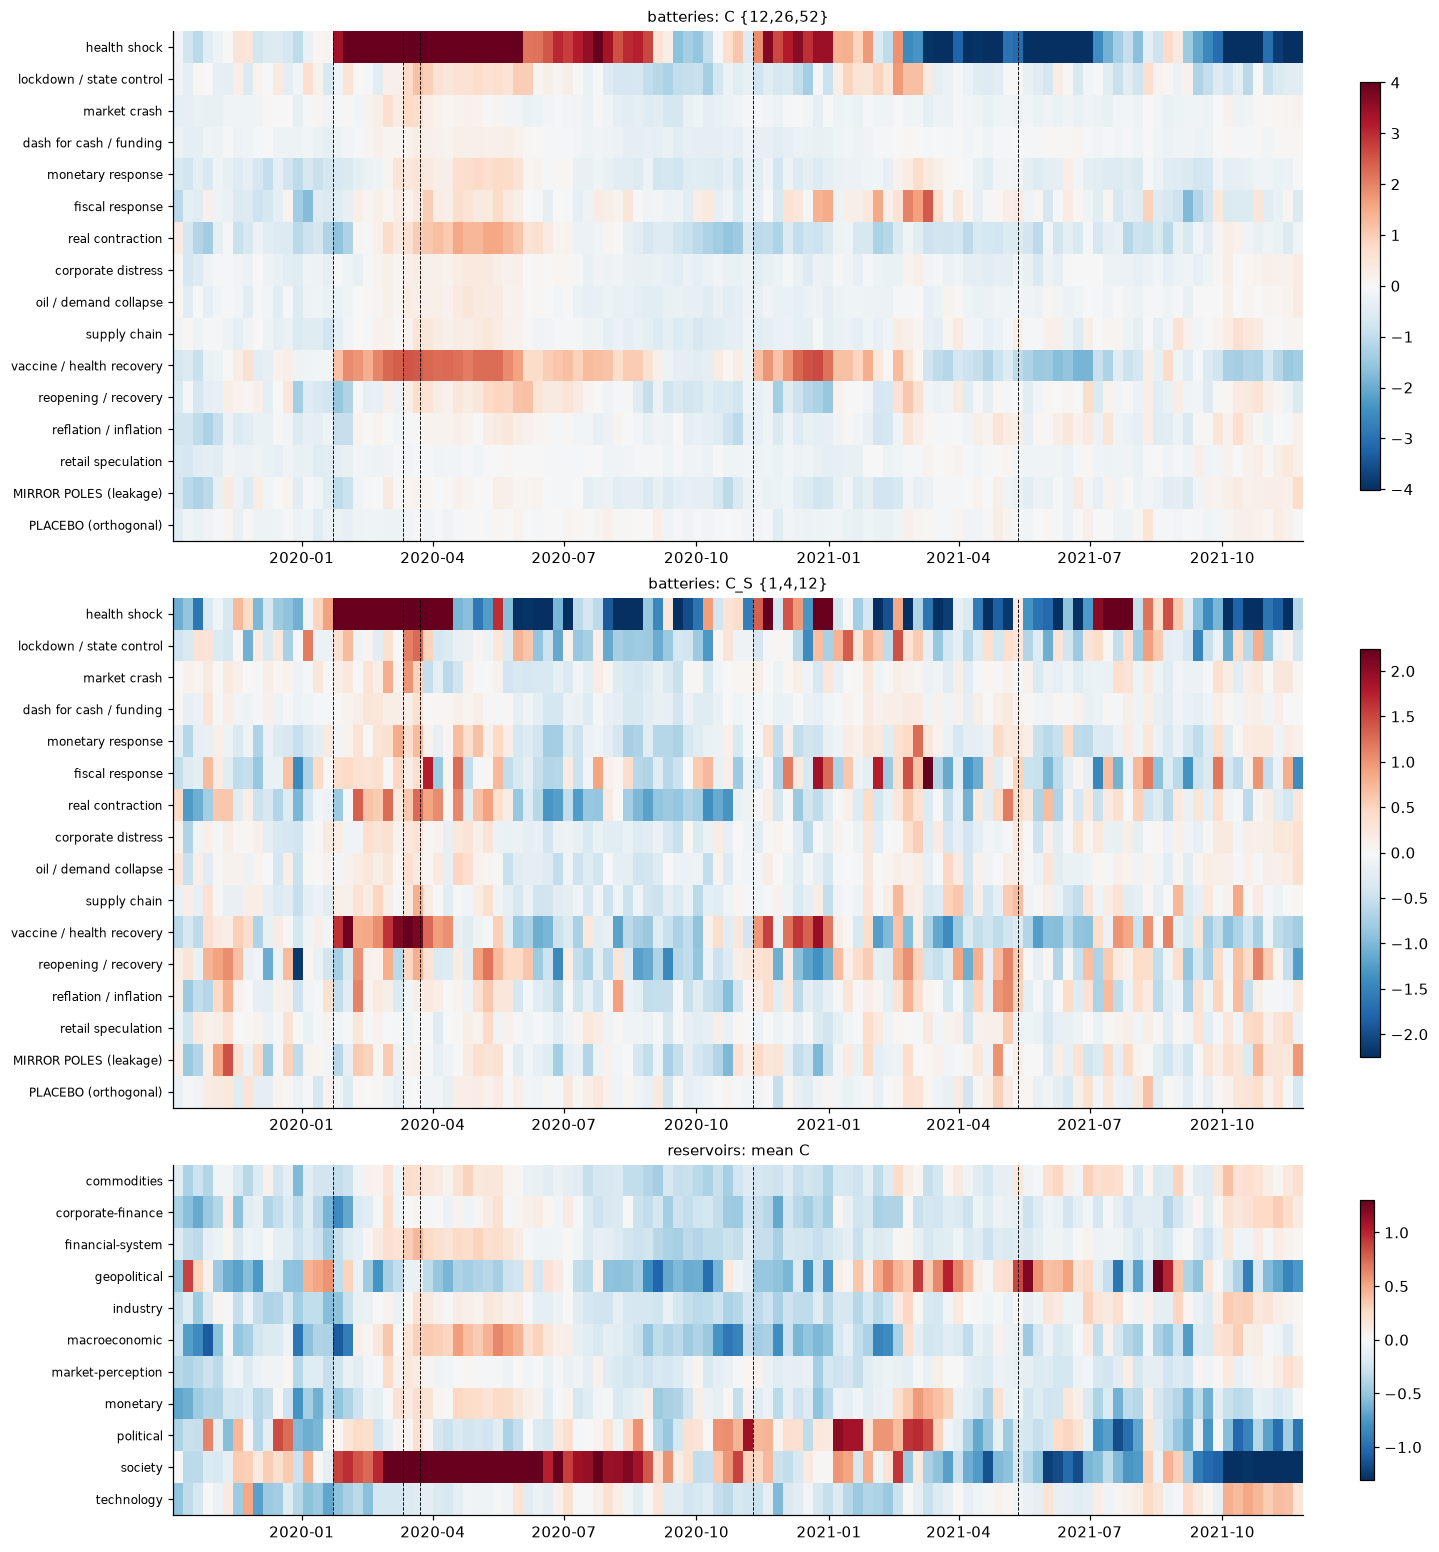

In [10]:
def heat(ax, frame, rows, title, vmax=None):
    m = frame.select(rows).to_numpy().T
    vmax = vmax or np.nanpercentile(np.abs(m), 98)
    x = mdates.date2num(frame["WEEK"].to_list())
    im = ax.imshow(m, aspect="auto", cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax),
                   extent=[x[0], x[-1], len(rows) - 0.5, -0.5], interpolation="nearest")
    ax.set_yticks(range(len(rows)), rows, fontsize=8); ax.xaxis_date(); ax.grid(False)
    for name in KEY_EVENTS:
        ax.axvline(EVENTS[name], color="k", lw=0.6, ls="--")
    ax.set_title(title, fontsize=10)
    return im


res = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(*VIEW))
       .join(NARR.select(KEY, "reservoir"), on=KEY)
       .group_by("WEEK", "reservoir").agg(pl.col("COMPOSITE").mean())
       .pivot(on="reservoir", index="WEEK", values="COMPOSITE").sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(13, 14), height_ratios=[len(blist), len(blist), res.width - 1])
fig.colorbar(heat(axes[0], v, blist, "batteries: C {12,26,52}"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], v_s, blist, "batteries: C_S {1,4,12}"), ax=axes[1], shrink=0.8)
fig.colorbar(heat(axes[2], res, sorted(res.columns[1:]), "reservoirs: mean C"), ax=axes[2], shrink=0.8)
plt.show()

### 4.1 Event table: permutation test and block-bootstrap baseline band

* `C`, `C_S`: battery composites in the event week (first Friday on/after the event).
* `perm_p`: share of `N_PERM` random equal-size batteries, same week, with a composite ≥ the
  battery's (controls for moves common to all narratives that week).
* `boot_p`: share of `N_BOOT` block-bootstrap draws of the battery's own **baseline** weekly
  composite (blocks of `BLOCK_WEEKS` weeks, preserving serial correlation) whose block maximum
  is ≥ the event value; a conservative "is this outside anything seen pre-Covid" test.

In [11]:
wk_arr = np.array(WEEKS.to_list())
col_of = {k: i for i, k in enumerate(C.columns)}
Cn = C.to_numpy()


def event_week(d):
    return min(int(np.searchsorted(wk_arr, d)), len(wk_arr) - 1)


def perm_p(row, idx, n_perm=N_PERM):
    # vectorised: n_perm random subsets of size k without replacement (argpartition of uniforms)
    x = row[~np.isnan(row)]
    obs = np.nanmean(row[idx])
    k = len(idx)
    pick = np.argpartition(RNG.random((n_perm, len(x))), k, axis=1)[:, :k]
    draws = x[pick].mean(axis=1)
    return obs, (1 + (draws >= obs).sum()) / (n_perm + 1)


def boot_block_max(series, n_boot=N_BOOT, block=BLOCK_WEEKS):
    # distribution of the max of one block drawn from the baseline series (moving-block bootstrap)
    s = series[~np.isnan(series)]
    starts = RNG.integers(0, len(s) - block + 1, n_boot)
    return np.array([s[i:i + block].max() for i in starts])


boot = {b: boot_block_max(base[b].to_numpy()) for b in blist}
rows = []
for ev, d in EVENTS.items():
    if not (VIEW[0] <= d <= VIEW[1]):
        continue
    i = event_week(d)
    i_s = min(int(np.searchsorted(np.array(WEEKS_S.to_list()), d)), bat_s.height - 1)
    for b in blist:
        idx = np.array([col_of[k] for k in BKEYS[b] if k in col_of])
        obs, p = perm_p(Cn[i], idx)
        rows.append({"event": ev, "week": wk_arr[i], "battery": b, "C": obs, "C_S": bat_s[b][i_s],
                     "z_vs_baseline": batz[b][i], "perm_p": p,
                     "boot_p": (1 + (boot[b] >= obs).sum()) / (N_BOOT + 1)})
ev_tab = pl.DataFrame(rows)
for col, dig in (("C", 2), ("C_S", 2), ("perm_p", 3), ("boot_p", 3)):
    print(col)
    display(ev_tab.pivot(on="event", index="battery", values=col).with_columns(pl.selectors.float().round(dig)))

C


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",-0.27,3.37,6.57,7.28,7.7,7.85,7.93,7.93,7.49,1.87,3.61,1.7,-3.93,-3.09,-4.12
"""lockdown / state control""",0.66,-0.16,0.19,0.22,0.77,1.16,0.95,0.95,0.57,-0.8,-0.95,0.48,0.37,-0.03,-0.44
"""market crash""",-0.04,-0.04,0.66,0.29,0.81,0.69,0.27,0.27,0.17,-0.07,-0.01,-0.08,-0.38,-0.23,0.16
"""dash for cash / funding""",-0.12,-0.21,0.12,0.12,0.15,0.28,0.19,0.19,0.21,-0.34,-0.25,-0.14,-0.07,-0.02,0.04
"""monetary response""",-0.63,-0.62,0.12,0.53,0.43,0.56,0.4,0.4,0.7,-0.42,-0.54,-0.18,0.37,-0.14,0.03
"""fiscal response""",-1.73,-0.49,0.08,0.28,0.15,0.42,0.98,0.98,0.56,-0.39,0.47,0.42,2.45,0.32,-0.59
"""real contraction""",-0.82,-1.6,0.73,0.35,0.6,1.02,1.08,1.08,1.32,-1.06,-0.99,-0.64,-0.83,-0.55,-0.13
"""corporate distress""",-0.17,-0.05,0.2,0.08,0.21,0.3,0.2,0.2,0.4,-0.42,-0.27,-0.05,-0.11,-0.13,0.33
"""oil / demand collapse""",-0.19,-0.26,0.19,0.11,0.29,0.25,0.2,0.2,0.49,-0.33,-0.36,-0.2,-0.34,-0.1,0.32


C_S


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",-0.07,4.07,4.91,6.63,7.25,7.05,5.47,5.47,-0.93,1.35,0.95,-0.39,-1.65,0.19,-0.64
"""lockdown / state control""",1.16,0.36,0.34,0.0,1.13,1.27,0.49,0.49,-0.16,-0.37,-0.6,0.82,-0.19,0.25,-0.38
"""market crash""",-0.05,0.14,0.81,0.06,0.99,0.52,-0.52,-0.52,0.09,0.14,0.13,0.24,-0.13,-0.02,0.07
"""dash for cash / funding""",-0.09,0.04,0.15,0.15,0.14,0.36,0.01,0.01,0.07,-0.1,-0.0,0.21,-0.1,0.08,-0.0
"""monetary response""",-0.33,-0.07,0.33,0.83,0.39,0.71,0.07,0.07,0.36,-0.03,-0.55,0.27,0.27,0.25,0.1
"""fiscal response""",-0.69,0.4,-0.02,0.46,0.16,0.37,1.76,1.76,-0.55,-0.28,0.23,-0.21,2.63,0.5,-1.41
"""real contraction""",-0.38,-0.81,1.25,0.22,0.6,1.28,0.88,0.88,-0.25,-0.04,-0.83,0.41,-0.31,0.42,0.25
"""corporate distress""",-0.06,0.17,0.34,0.08,0.24,0.33,0.05,0.05,0.3,-0.26,-0.25,0.26,-0.24,0.24,0.34
"""oil / demand collapse""",0.03,-0.06,0.28,0.04,0.38,0.21,0.05,0.05,0.37,-0.06,-0.28,0.25,-0.19,0.17,0.35


perm_p


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",0.514,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009,0.0,0.008,1.0,1.0,1.0
"""lockdown / state control""",0.052,0.205,0.341,0.162,0.049,0.034,0.04,0.039,0.104,0.98,0.965,0.047,0.17,0.47,0.763
"""market crash""",0.225,0.083,0.06,0.09,0.051,0.078,0.232,0.228,0.396,0.203,0.131,0.384,0.905,0.831,0.095
"""dash for cash / funding""",0.309,0.196,0.456,0.245,0.38,0.319,0.328,0.328,0.318,0.681,0.404,0.494,0.556,0.477,0.22
"""monetary response""",0.932,0.771,0.451,0.055,0.101,0.106,0.132,0.131,0.07,0.822,0.883,0.581,0.099,0.712,0.239
"""fiscal response""",1.0,0.615,0.503,0.105,0.387,0.198,0.041,0.038,0.102,0.714,0.036,0.045,0.0,0.14,0.85
"""real contraction""",0.984,0.998,0.052,0.073,0.061,0.056,0.048,0.046,0.021,1.0,0.998,0.989,0.988,0.97,0.468
"""corporate distress""",0.376,0.098,0.334,0.318,0.299,0.299,0.308,0.311,0.15,0.808,0.463,0.324,0.61,0.682,0.023
"""oil / demand collapse""",0.406,0.29,0.351,0.282,0.206,0.375,0.323,0.321,0.109,0.629,0.62,0.602,0.865,0.627,0.036


boot_p


battery,WHO notified (Wuhan),Wuhan lockdown,Italy outbreak,Fed emergency cut,WHO pandemic,Fed to zero + QE,Unlimited QE / trough,CARES Act,Negative WTI,Pfizer efficacy,First vaccination (UK),GameStop squeeze,American Rescue Plan,CPI surprise (Apr print),Omicron named
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""health shock""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
"""lockdown / state control""",0.517,1.0,0.836,0.836,0.502,0.103,0.408,0.408,0.561,1.0,1.0,0.597,0.608,0.923,1.0
"""market crash""",0.947,0.947,0.085,0.467,0.085,0.085,0.467,0.467,0.629,0.947,0.928,0.947,0.978,0.958,0.629
"""dash for cash / funding""",0.888,1.0,0.708,0.708,0.675,0.434,0.598,0.598,0.571,1.0,1.0,0.981,0.819,0.794,0.733
"""monetary response""",1.0,1.0,0.969,0.641,0.684,0.434,0.694,0.694,0.229,1.0,1.0,0.987,0.773,0.976,0.969
"""fiscal response""",1.0,1.0,0.798,0.775,0.798,0.695,0.418,0.418,0.585,1.0,0.585,0.695,0.0,0.775,1.0
"""real contraction""",1.0,1.0,0.57,0.776,0.57,0.336,0.274,0.274,0.118,1.0,1.0,1.0,1.0,1.0,1.0
"""corporate distress""",0.935,0.915,0.705,0.831,0.705,0.506,0.705,0.705,0.506,1.0,1.0,0.915,0.935,0.935,0.506
"""oil / demand collapse""",0.905,1.0,0.644,0.778,0.59,0.632,0.644,0.644,0.129,1.0,1.0,0.905,1.0,0.846,0.506


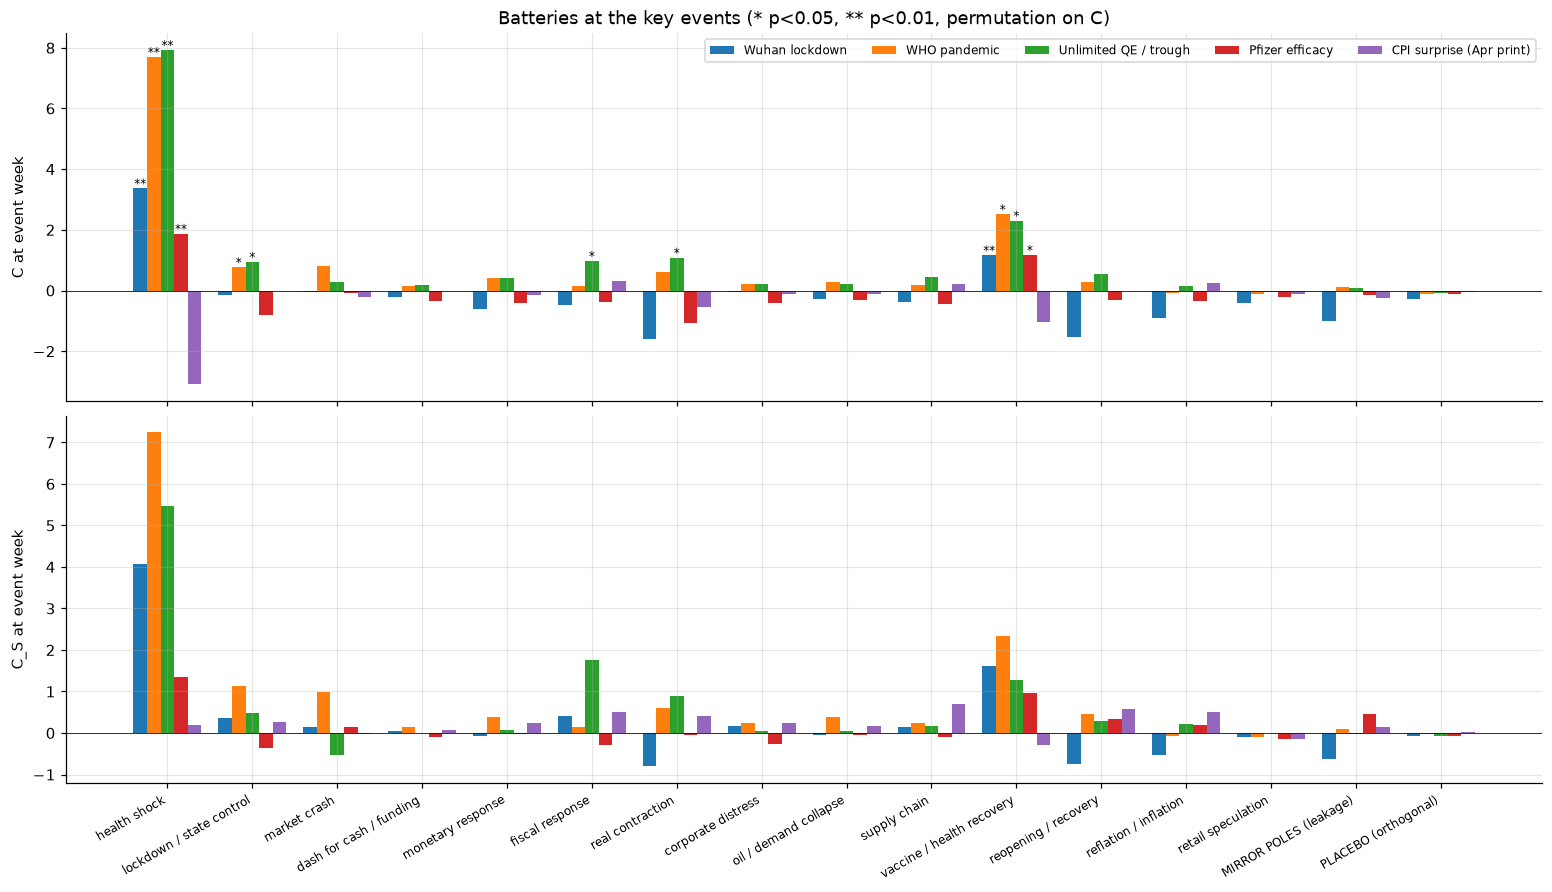

In [12]:
pz = ev_tab.filter(pl.col("event").is_in(list(KEY_EVENTS)))
evs = [e for e in KEY_EVENTS if e in pz["event"].unique().to_list()]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, col in zip(axes, ("C", "C_S")):
    wbar = 0.8 / max(len(evs), 1)
    for j, e in enumerate(evs):
        g = pz.filter(pl.col("event") == e).sort(pl.col("battery").replace_strict({b: i for i, b in enumerate(blist)}))
        xs_ = np.arange(len(blist)) + j * wbar
        ax.bar(xs_, g[col], width=wbar, label=e)
        if col == "C":
            for x_, c_, p_ in zip(xs_, g["C"], g["perm_p"]):
                if p_ < 0.05:
                    ax.text(x_, c_ + (0.03 if c_ >= 0 else -0.12), "*" if p_ >= 0.01 else "**",
                            ha="center", fontsize=8)
    ax.axhline(0, color="k", lw=0.5); ax.set_ylabel(f"{col} at event week")
axes[1].set_xticks(np.arange(len(blist)) + 0.4 - wbar / 2, blist, rotation=30, ha="right", fontsize=8)
axes[0].legend(fontsize=8, ncol=len(evs)); axes[0].set_title("Batteries at the key events (* p<0.05, ** p<0.01, permutation on C)")
plt.show()

## 5. Horizon term structure at the key events

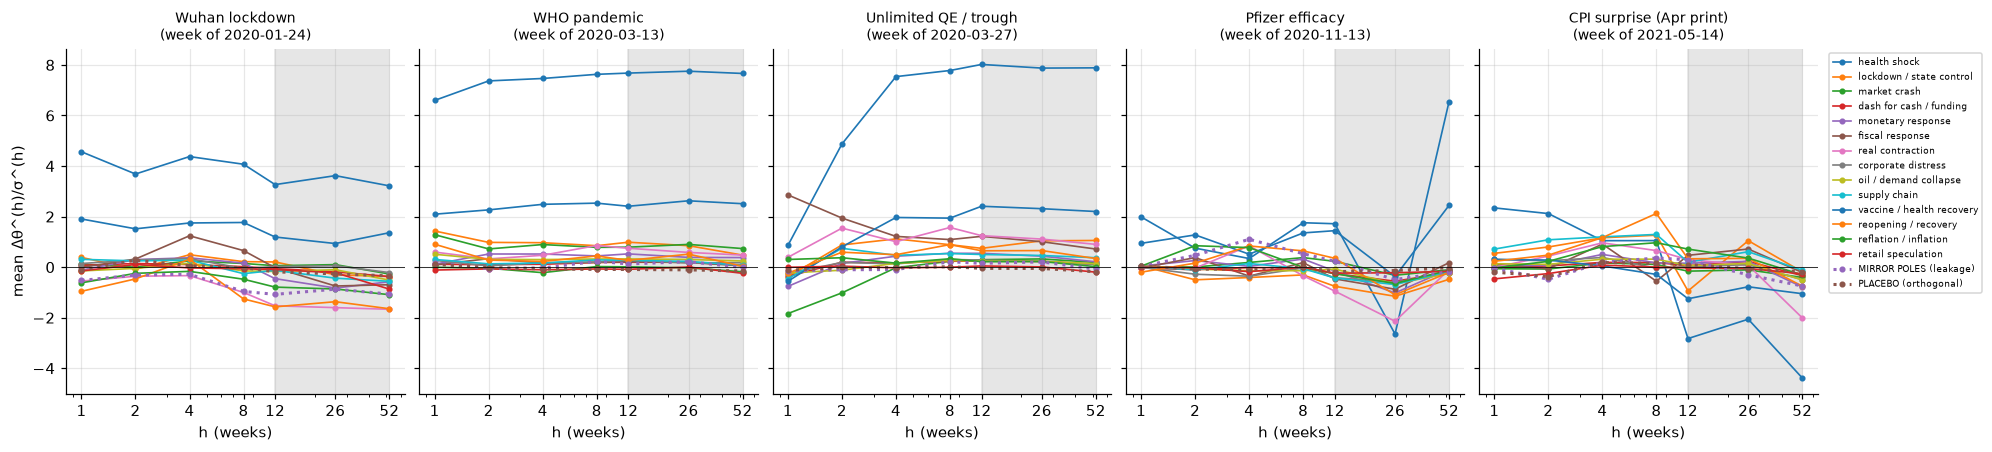

In [13]:
term = panel.select("WEEK", KEY, *[f"Z{h}" for h in ALL_H])
fig, axes = plt.subplots(1, len(KEY_EVENTS), figsize=(18, 4), sharey=True)
for ax, e in zip(axes, KEY_EVENTS):
    wk = wk_arr[event_week(EVENTS[e])]
    t = term.filter(pl.col("WEEK") == wk)
    for b in blist:
        g = t.filter(pl.col(KEY).is_in(BKEYS[b])).select([pl.col(f"Z{h}").mean() for h in ALL_H]).row(0)
        diag = b in DIAGNOSTIC
        ax.plot(ALL_H, g, marker="o", ms=3, lw=2 if diag else 1.1, ls=":" if diag else "-", label=b)
    ax.axhline(0, color="k", lw=0.5); ax.set_xscale("log"); ax.set_xticks(ALL_H, [str(h) for h in ALL_H])
    ax.axvspan(min(COMPOSITE_H), max(COMPOSITE_H), color="0.9", zorder=0)
    ax.set_title(f"{e}\n(week of {wk})", fontsize=9); ax.set_xlabel("h (weeks)")
axes[0].set_ylabel("mean Δθ^(h)/σ^(h)")
axes[-1].legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 6. Unsupervised cross-sections

All 419 narrative keys ranked by the short composite in the crash (Feb-24 → Apr-3 2020) and by
the long composite in the vaccine/reflation phase (Nov-2020 → Jun-2021). Colour = reservoir.

crash (C_S): battery narratives among top 25 = 14 (chance ≈ 4.5)
vaccine / reflation (C): battery narratives among top 25 = 3 (chance ≈ 4.5)


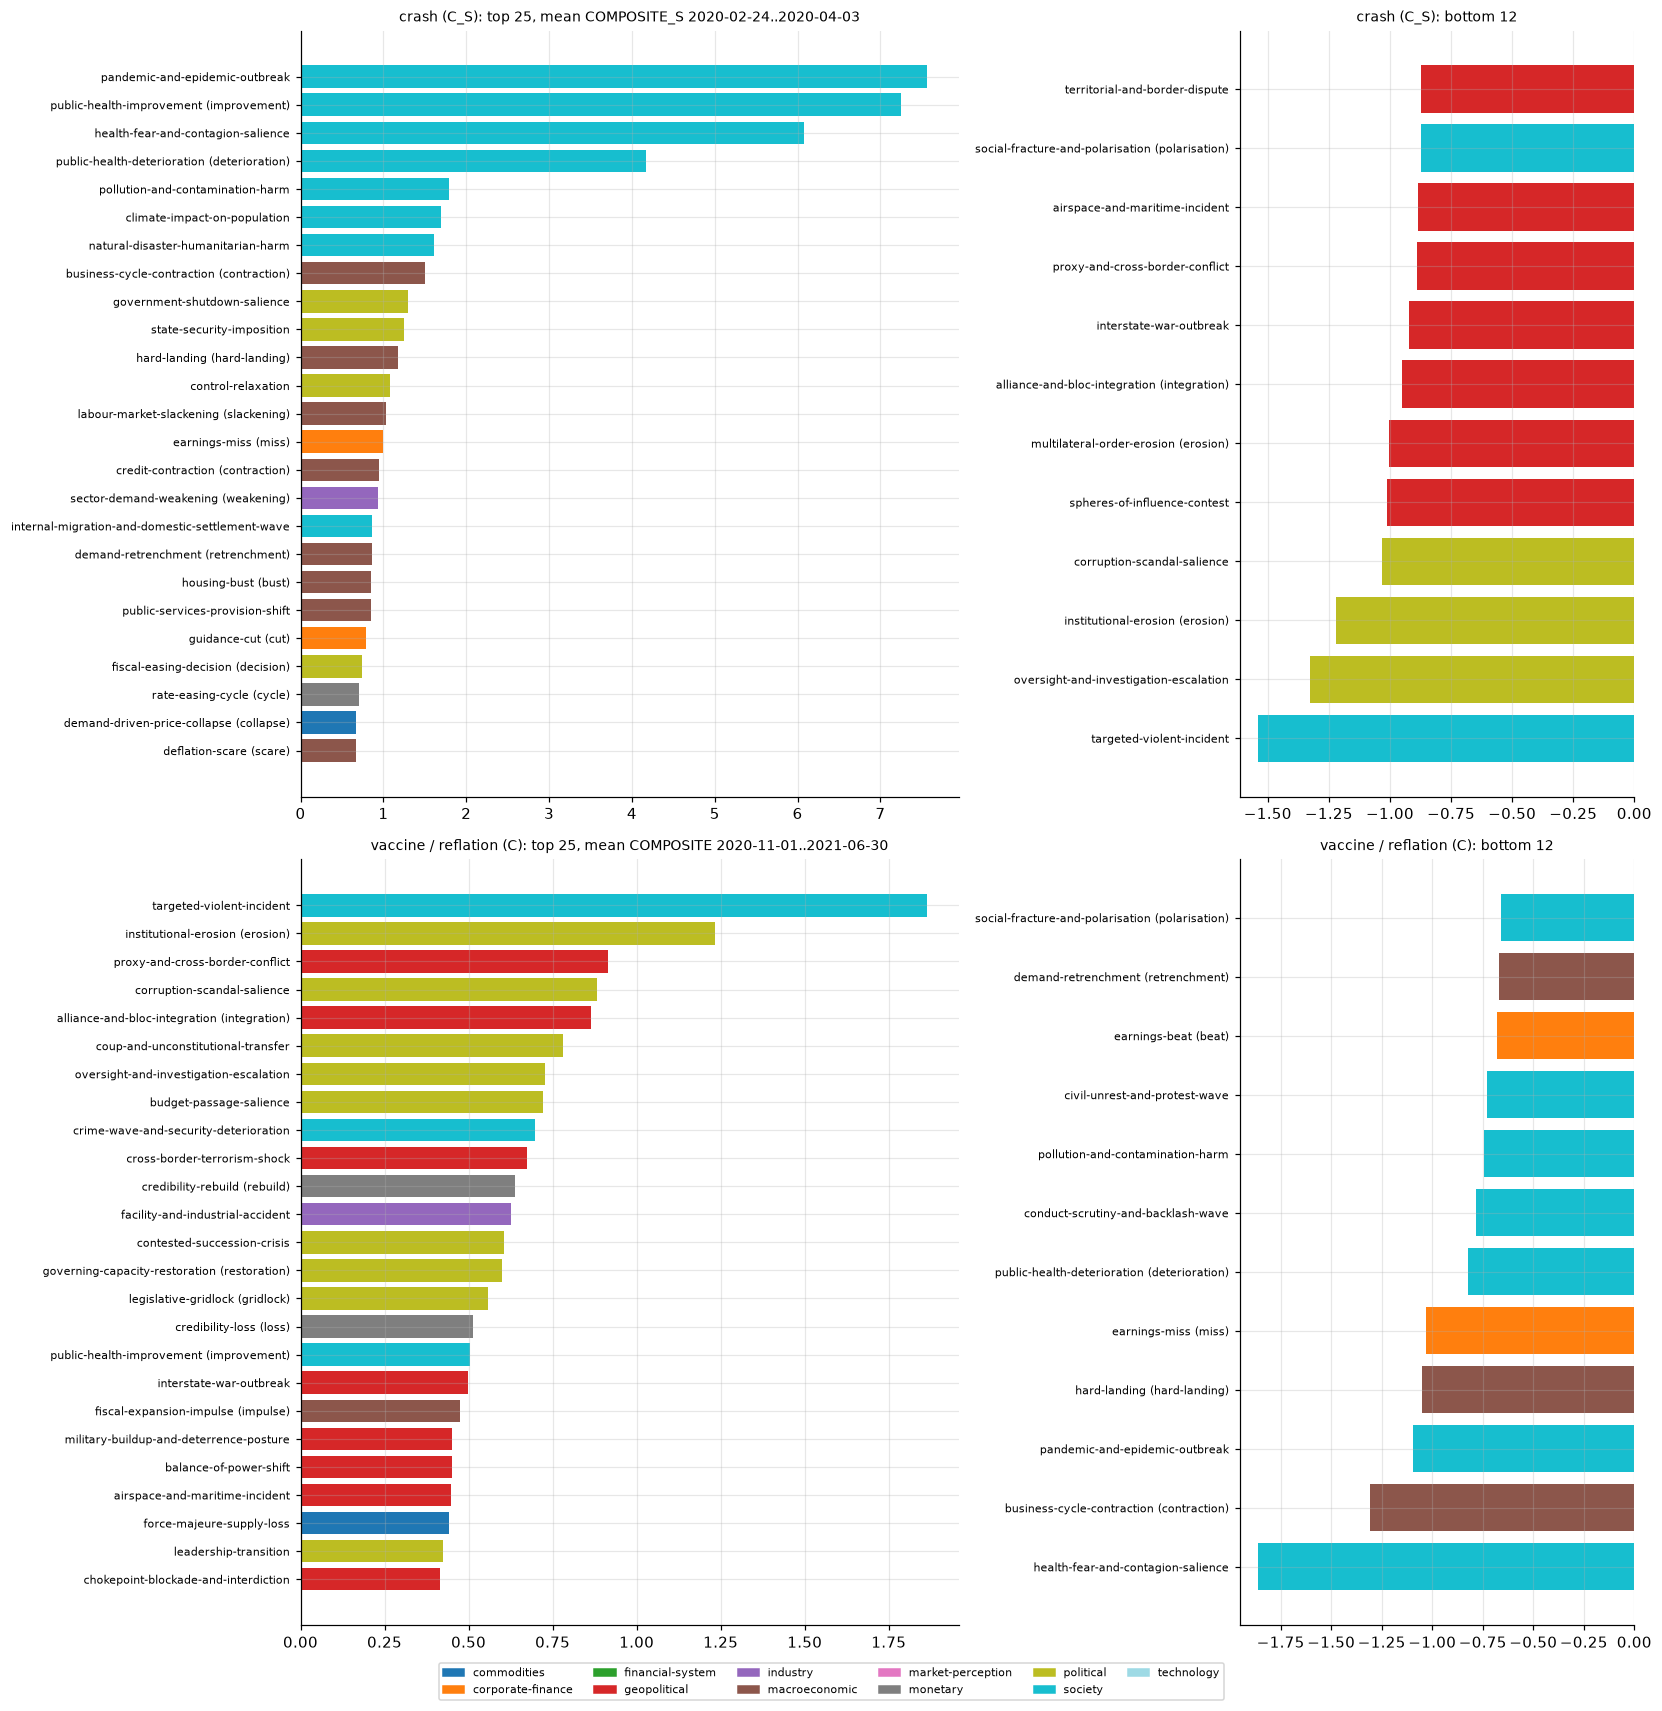

In [14]:
resv = sorted(NARR["reservoir"].unique().to_list())
cmap = dict(zip(resv, plt.cm.tab20(np.linspace(0, 1, len(resv)))))
in_b = {k for b in blist if b not in DIAGNOSTIC for k in BKEYS[b]}


def ranked(col, lo, hi):
    return (panel.filter(pl.col("WEEK").is_between(lo, hi) & pl.col(col).is_not_null())
            .group_by(KEY).agg(pl.col(col).mean().alias("V")).join(NARR, on=KEY).sort("V", descending=True))


def barplot(ax, t, title):
    lab = [f"{r['narrative']} ({r['pole']})" if r["pole"] else r["narrative"] for r in t.iter_rows(named=True)]
    ax.barh(range(t.height), t["V"], color=[cmap[r] for r in t["reservoir"]])
    ax.set_yticks(range(t.height), lab, fontsize=7); ax.invert_yaxis(); ax.set_title(title, fontsize=9)


phases = {"crash (C_S)": ("COMPOSITE_S", date(2020, 2, 24), date(2020, 4, 3)),
          "vaccine / reflation (C)": ("COMPOSITE", date(2020, 11, 1), date(2021, 6, 30))}
fig, axes = plt.subplots(2, 2, figsize=(15, 15), width_ratios=[5, 3])
for row, (name, (col, lo, hi)) in enumerate(phases.items()):
    r = ranked(col, lo, hi)
    barplot(axes[row, 0], r.head(25), f"{name}: top 25, mean {col} {lo}..{hi}")
    barplot(axes[row, 1], r.tail(12), f"{name}: bottom 12")
    print(f"{name}: battery narratives among top 25 = {r.head(25).filter(pl.col(KEY).is_in(in_b)).height} "
          f"(chance ≈ {25 * len(in_b) / r.height:.1f})")
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[r]) for r in resv]
fig.legend(handles, resv, fontsize=7, loc="lower center", ncol=min(6, len(resv)), bbox_to_anchor=(0.5, -0.03))
plt.show()

## 7. Narrative waves: onset and peak timing

Onset = first week in the window where the battery's C_S exceeds `ONSET_THRESHOLD` (C_S because
Covid is abrupt); peak = arg-max of C over the window. Expected ordering: health shock →
market crash / dash for cash → monetary → fiscal → real contraction / distress / oil → supply
chain → vaccine → reopening → reflation (with retail speculation in early 2021).

battery,onset_CS,peak_C,max_C,max_CS,weeks_CS_lit
str,date,date,f64,f64,i64
"""market crash""",null,2020-03-13,0.81,0.99,0
"""dash for cash / funding""",null,2020-03-20,0.28,0.36,0
"""health shock""",2020-01-24,2020-04-10,8.08,7.25,24
"""real contraction""",2020-02-07,2020-04-17,1.56,1.34,6
"""corporate distress""",null,2020-04-24,0.4,0.55,0
"""oil / demand collapse""",null,2020-04-24,0.49,0.49,0
"""monetary response""",2021-03-05,2020-05-15,0.76,1.26,1
"""reopening / recovery""",2019-11-08,2020-06-05,1.17,1.21,6
"""vaccine / health recovery""",2020-01-24,2020-12-25,2.64,2.33,17


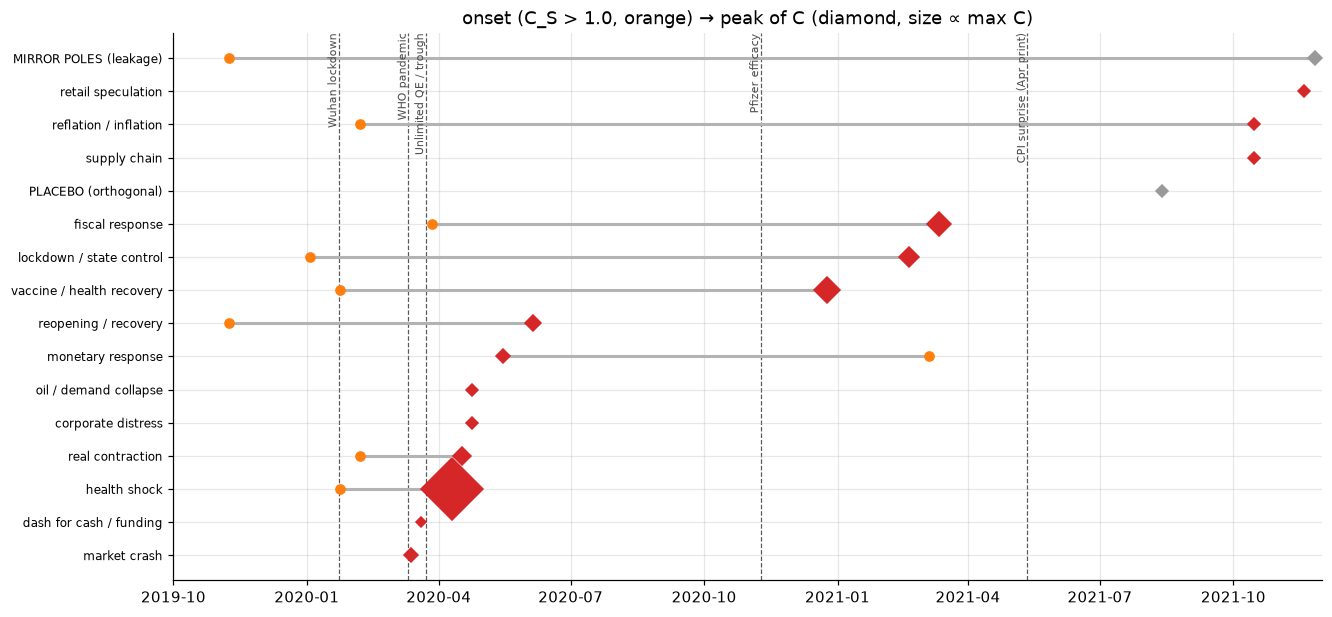

In [15]:
win = v.join(v_s, on="WEEK", suffix="_S")
wv = []
for b in blist:
    ys = win[f"{b}_S"].to_numpy(); y = win[b].to_numpy()
    on = np.flatnonzero(ys > ONSET_THRESHOLD)
    wv.append({"battery": b, "onset_CS": win["WEEK"][int(on[0])] if on.size else None,
               "peak_C": win["WEEK"][int(np.nanargmax(y))], "max_C": float(np.nanmax(y)),
               "max_CS": float(np.nanmax(ys)), "weeks_CS_lit": int(on.size)})
waves = pl.DataFrame(wv).sort("peak_C")
display(waves.with_columns(pl.selectors.float().round(2)))

fig, ax = plt.subplots(figsize=(12, 5.5))
for i, r in enumerate(waves.iter_rows(named=True)):
    col = "0.6" if r["battery"] in DIAGNOSTIC else "tab:red"
    if r["onset_CS"] is not None:
        ax.plot([r["onset_CS"], r["peak_C"]], [i, i], color="0.7", lw=2)
        ax.plot(r["onset_CS"], i, "o", color="tab:orange")
    ax.plot(r["peak_C"], i, "D", color=col, ms=4 + 3 * max(r["max_C"], 0))
ax.set_yticks(range(waves.height), waves["battery"], fontsize=8)
date_axis(ax); shade_events(ax)
ax.set_title(f"onset (C_S > {ONSET_THRESHOLD}, orange) → peak of C (diamond, size ∝ max C)")
plt.show()

In [16]:
# the leading narratives of each quarter (mean C), 2019Q4 .. end of window
q = (panel.filter(pl.col("WEEK").is_between(*VIEW) & pl.col("COMPOSITE").is_not_null())
     .with_columns(pl.col("WEEK").dt.truncate("1q").alias("Q"))
     .group_by("Q", KEY).agg(pl.col("COMPOSITE").mean())
     .join(NARR.select(KEY, "narrative", "pole"), on=KEY)
     .with_columns(pl.when(pl.col("pole").fill_null("") != "").then(pl.format("{} ({})", "narrative", "pole"))
                   .otherwise(pl.col("narrative")).alias("label"))
     .sort("Q", "COMPOSITE", descending=[False, True])
     .group_by("Q", maintain_order=True).head(5)
     .with_columns(pl.format("{} {}", pl.col("label"), pl.col("COMPOSITE").round(2)).alias("top"))
     .group_by("Q", maintain_order=True).agg(pl.col("top"))
     .with_columns(pl.col("Q").dt.strftime("%Y-%m"), *[pl.col("top").list.get(i, null_on_oob=True).alias(f"#{i+1}")
                                                       for i in range(5)])
     .drop("top"))
q

Q,#1,#2,#3,#4,#5
str,str,str,str,str,str
"""2019-10""","""oversight-and-investigation-escalation 2.23""","""civil-unrest-and-protest-wave 1.67""","""corruption-scandal-salience 1.62""","""legislative-gridlock (gridlock) 1.08""","""institutional-erosion (erosion) 0.99"""
"""2020-01""","""public-health-improvement (improvement) 6.9""","""pandemic-and-epidemic-outbreak 6.75""","""health-fear-and-contagion-salience 5.28""","""natural-disaster-humanitarian-harm 2.5""","""public-health-deterioration (deterioration) 2.01"""
"""2020-04""","""public-health-improvement (improvement) 7.25""","""pandemic-and-epidemic-outbreak 6.86""","""public-health-deterioration (deterioration) 5.33""","""health-fear-and-contagion-salience 4.89""","""climate-impact-on-population 2.31"""
"""2020-07""","""public-health-improvement (improvement) 2.37""","""climate-impact-on-population 2.37""","""pandemic-and-epidemic-outbreak 2.31""","""health-fear-and-contagion-salience 1.92""","""public-health-deterioration (deterioration) 1.88"""
"""2020-10""","""electoral-cycle-uncertainty 4.27""","""public-health-improvement (improvement) 3.97""","""mandate-strengthening (strengthening) 3.04""","""mandate-weakening (weakening) 2.81""","""pandemic-and-epidemic-outbreak 2.51"""
"""2021-01""","""targeted-violent-incident 2.75""","""coup-and-unconstitutional-transfer 2.46""","""corruption-scandal-salience 2.28""","""institutional-erosion (erosion) 2.13""","""oversight-and-investigation-escalation 1.97"""
"""2021-04""","""targeted-violent-incident 3.35""","""proxy-and-cross-border-conflict 1.65""","""facility-and-industrial-accident 1.49""","""airspace-and-maritime-incident 1.39""","""crime-wave-and-security-deterioration 1.37"""
"""2021-07""","""natural-disaster-humanitarian-harm 3.57""","""conflict-driven-migration-and-refugee-crisis 2.36""","""force-majeure-supply-loss 1.24""","""facility-and-industrial-accident 1.15""","""interstate-war-outbreak 1.1"""
"""2021-10""","""capex-upswing (upswing) 1.89""","""capacity-expansion (expansion) 1.25""","""foundational-discovery-expanding-feasible-set 1.21""","""dominant-design-emergence (emergence) 0.99""","""governance-soundness (soundness) 0.82"""


## 8. Pole leakage diagnostic

For each bipolar dimension, the correlation (over window weeks) between the weekly θ̄ of its
two most-opposed poles. With a direction-aware signal these would be negatively correlated or
unrelated during a one-sided shock; strongly positive correlations mean the scorer assigns
attention to the *topic* and both poles move together.

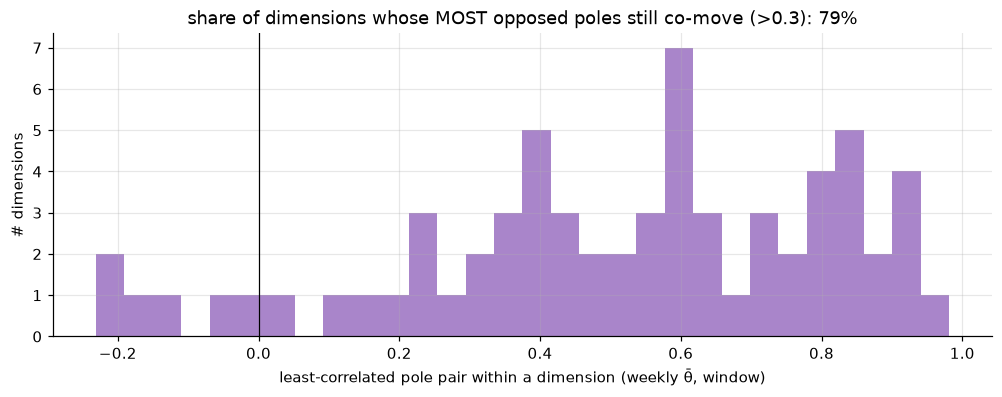

dimension,pole_a,pole_b,min_corr,mean_offdiag_corr
str,str,str,f64,f64
"""political|political-power-tenure""","""mandate-strengthening (strengthening)""","""mandate-weakening (weakening)""",0.98,0.98
"""macroeconomic|labour-market-slack""","""labour-market-slackening (slackening)""","""labour-market-tightening (tightening)""",0.93,0.93
"""monetary|cross-border-monetary-conditions""","""global-liquidity-easing (easing)""","""global-liquidity-tightening (tightening)""",0.92,0.92
"""society|public-health-condition""","""public-health-deterioration (deterioration)""","""public-health-improvement (improvement)""",0.92,0.92
"""monetary|policy-guidance-and-reaction-function""","""dovish-guidance-shift (shift)""","""hawkish-guidance-shift (shift)""",0.9,0.9
"""macroeconomic|aggregate-corporate-profitability""","""profit-cycle-upturn (upturn)""","""margin-compression (compression)""",0.9,0.9
"""political|fiscal-tax-policy-direction""","""fiscal-easing-decision (decision)""","""fiscal-tightening-decision (decision)""",0.87,0.87
"""financial-system|funding-and-liquidity-condition""","""funding-squeeze (squeeze)""","""cross-border-dollar-funding-stress (stress)""",0.86,0.86
"""corporate-finance|equity-capital-actions""","""equity-issuance (issuance)""","""share-buyback (buyback)""",0.85,0.85


In [17]:
wk_theta = (panel.filter(pl.col("WEEK").is_between(*VIEW)).select("WEEK", KEY, "THETA_W")
            .join(NARR, on=KEY))
signed = NARR.filter(pl.col("pole").fill_null("") != "")
KEY_LABEL = {r[KEY]: f"{r['narrative']} ({r['pole']})" for r in signed.iter_rows(named=True)}
pairs = []
for (res_, dim), g in signed.group_by("reservoir", "dimension"):
    ks = g[KEY].to_list()
    if len(ks) < 2:
        continue
    m = (wk_theta.filter(pl.col(KEY).is_in(ks)).pivot(on=KEY, index="WEEK", values="THETA_W")
         .drop("WEEK").drop_nulls())
    if m.height < 20:
        continue
    cm = np.corrcoef(m.to_numpy().T)
    i, j = np.unravel_index(np.argmin(cm + np.eye(len(cm)) * 9), cm.shape)
    pairs.append({"dimension": f"{res_}|{dim}", "pole_a": KEY_LABEL[m.columns[i]],
                  "pole_b": KEY_LABEL[m.columns[j]], "min_corr": cm[i, j],
                  "mean_offdiag_corr": (cm.sum() - len(cm)) / (len(cm) ** 2 - len(cm))})
leak = pl.DataFrame(pairs).sort("min_corr", descending=True)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(leak["min_corr"], bins=30, color="tab:purple", alpha=0.8)
ax.axvline(0, color="k", lw=0.8); ax.set_xlabel("least-correlated pole pair within a dimension (weekly θ̄, window)")
ax.set_ylabel("# dimensions"); ax.set_title(f"share of dimensions whose MOST opposed poles still co-move (>0.3): "
                                            f"{(leak['min_corr'] > 0.3).mean():.0%}")
plt.show()
leak.head(15).with_columns(pl.selectors.float().round(2))

## 9. Topic-level (direction-free) view

Attention summed over every narrative of a dimension (`reservoir|dimension`, poles pooled), then
the same stages 1–5. This is the quantity attention actually measures without ambiguity.

{'public health': 1, 'market volatility': 3, 'funding & plumbing': 3, 'monetary policy': 3, 'fiscal': 2, 'output & labour': 3, 'supply chain': 3, 'prices': 1, 'state control': 2, 'PLACEBO (orthogonal)': 3}


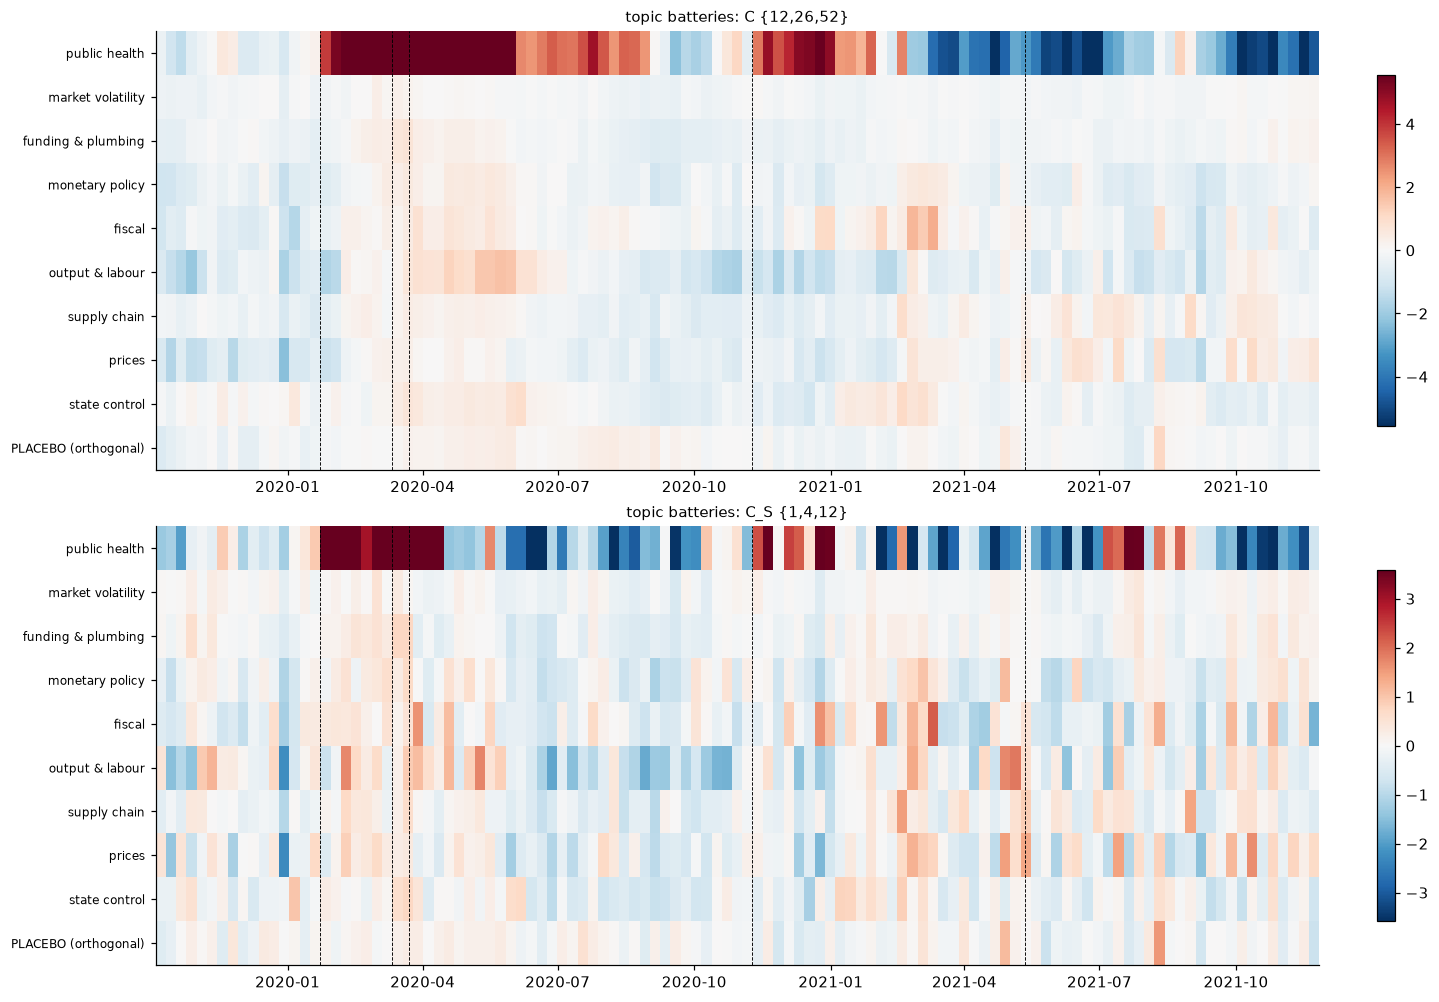

top / bottom dimensions in the crash (C_S) with their vaccine/reflation-phase C


narrative_key,C_S_crash,C_vaccine_reflation
str,f64,f64
"""society|public-health-condition""",6.58,-0.88
"""society|environmental-harm-to-population""",1.36,-0.53
"""macroeconomic|aggregate-output-and-cycle""",0.68,-1.04
"""macroeconomic|labour-market-slack""",0.65,-0.45
"""corporate-finance|issuer-profitability""",0.63,-1.15
"""political|domestic-order-and-state-security""",0.59,-0.01
"""financial-system|market-functioning-and-microstructure""",0.52,-0.27
"""macroeconomic|fiscal-stance-impulse""",0.5,0.03
"""commodities|resource-price-and-volatility""",0.47,-0.37


In [18]:
topic_daily = (daily.group_by("DATE", "reservoir", "dimension")
               .agg(pl.col("THETA").sum(), pl.col("N_HEADLINES").first())
               .with_columns(pl.format("{}|{}", "reservoir", "dimension").alias(KEY)))
tpanel = post_process(topic_daily)
TKEYS = {b: [k for k in ks if k in set(tpanel[KEY].unique().to_list())] for b, ks in TOPIC_BATTERIES.items()}
print({b: len(k) for b, k in TKEYS.items()})
TW, TC, tbat = battery_frame(tpanel, "COMPOSITE", TKEYS)
_, _, tbat_s = battery_frame(tpanel, "COMPOSITE_S", TKEYS)
tv = tbat.filter(pl.col("WEEK").is_between(*VIEW)); tv_s = tbat_s.filter(pl.col("WEEK").is_between(*VIEW))
tlist = [b for b in TKEYS if TKEYS[b]]
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.colorbar(heat(axes[0], tv, tlist, "topic batteries: C {12,26,52}"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], tv_s, tlist, "topic batteries: C_S {1,4,12}"), ax=axes[1], shrink=0.8)
plt.show()

trank = (tpanel.filter(pl.col("WEEK").is_between(date(2020, 2, 24), date(2020, 4, 3)) & pl.col("COMPOSITE_S").is_not_null())
         .group_by(KEY).agg(pl.col("COMPOSITE_S").mean().alias("C_S_crash"))
         .join(tpanel.filter(pl.col("WEEK").is_between(date(2020, 11, 1), date(2021, 6, 30)))
               .group_by(KEY).agg(pl.col("COMPOSITE").mean().alias("C_vaccine_reflation")), on=KEY)
         .sort("C_S_crash", descending=True))
print("top / bottom dimensions in the crash (C_S) with their vaccine/reflation-phase C")
display(pl.concat([trank.head(12), trank.tail(6)]).with_columns(pl.selectors.float().round(2)))

## 10. Robustness: stage-1 variants

corr(C spec, C trailing 5y seasonal) over the window = 0.939
corr(C spec, C no stage 1) over the window = 0.887


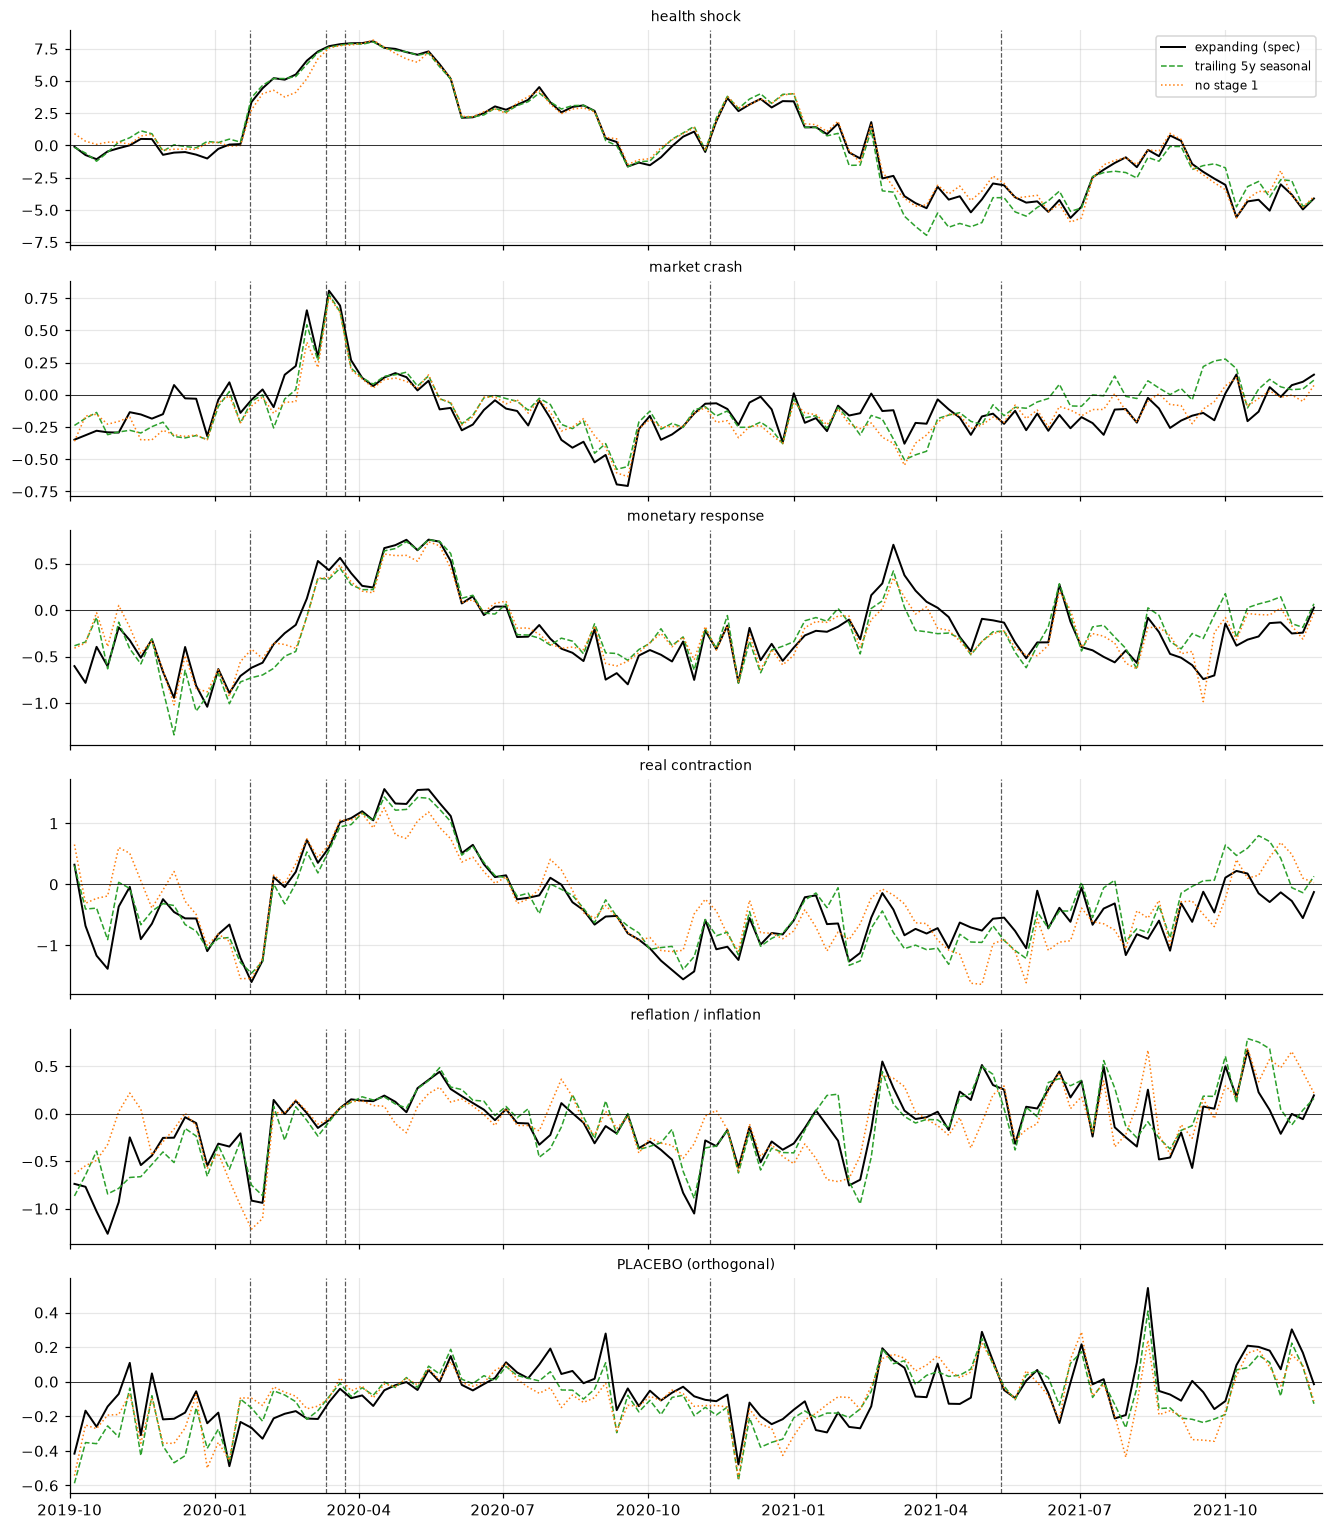

In [19]:
variants = {"expanding (spec)": panel,
            f"trailing {SEASONAL_YEARS_ROBUST}y seasonal": post_process(daily, seasonal_years=SEASONAL_YEARS_ROBUST),
            "no stage 1": post_process(daily, deseason=False)}
ref = panel.select("WEEK", KEY, "COMPOSITE")
for name, p in list(variants.items())[1:]:
    j = ref.join(p.select("WEEK", KEY, pl.col("COMPOSITE").alias("ALT")), on=["WEEK", KEY]).drop_nulls()
    j = j.filter(pl.col("WEEK").is_between(*VIEW))
    print(f"corr(C spec, C {name}) over the window = {np.corrcoef(j['COMPOSITE'], j['ALT'])[0, 1]:.3f}")

show = [b for b in ("health shock", "market crash", "monetary response", "real contraction",
                    "reflation / inflation", PLACEBO) if b in blist]
fig, axes = plt.subplots(len(show), 1, figsize=(12, 2.3 * len(show)), sharex=True)
styles = {"expanding (spec)": ("k", "-", 1.3), f"trailing {SEASONAL_YEARS_ROBUST}y seasonal": ("tab:green", "--", 1),
          "no stage 1": ("tab:orange", ":", 1)}
for name, p in variants.items():
    _, _, b_ = battery_frame(p, "COMPOSITE", {b: BKEYS[b] for b in show})
    b_ = b_.filter(pl.col("WEEK").is_between(*VIEW))
    for ax, b in zip(np.atleast_1d(axes), show):
        c, ls, lw = styles[name]
        ax.plot(b_["WEEK"], b_[b], color=c, ls=ls, lw=lw, label=name)
for ax, b in zip(np.atleast_1d(axes), show):
    ax.axhline(0, color="k", lw=0.5); ax.set_title(b, fontsize=9); date_axis(ax); shade_events(ax, labels=False)
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.show()

In [20]:
# summary per battery: baseline vs Covid phases
phases_ = {"baseline": BASELINE, "shock (Feb–May 20)": (date(2020, 2, 17), date(2020, 5, 31)),
           "vaccine (Nov 20–Mar 21)": (date(2020, 11, 1), date(2021, 3, 31)),
           "reflation (Apr–Nov 21)": (date(2021, 4, 1), VIEW[1])}
summ = []
for b in blist:
    r = {"battery": b}
    for name, (lo_, hi_) in phases_.items():
        r[f"C {name}"] = bat.filter(pl.col("WEEK").is_between(lo_, hi_))[b].mean()
    r["max z (window)"] = batz.filter(pl.col("WEEK").is_between(*VIEW))[b].max()
    summ.append(r)
pl.DataFrame(summ).with_columns(pl.selectors.float().round(2))

battery,C baseline,C shock (Feb–May 20),C vaccine (Nov 20–Mar 21),C reflation (Apr–Nov 21),max z (window)
str,f64,f64,f64,f64,f64
"""health shock""",0.02,7.13,0.56,-3.2,10.1
"""lockdown / state control""",0.13,0.56,0.07,-0.36,3.21
"""market crash""",-0.03,0.23,-0.15,-0.13,2.77
"""dash for cash / funding""",0.03,0.19,-0.16,-0.06,1.18
"""monetary response""",0.08,0.48,-0.15,-0.3,1.93
"""fiscal response""",0.01,0.4,0.59,-0.24,3.61
"""real contraction""",0.13,1.07,-0.72,-0.49,2.48
"""corporate distress""",0.07,0.23,-0.18,-0.14,1.04
"""oil / demand collapse""",0.06,0.25,-0.2,-0.06,1.65


## 11. Reading guide / caveats

* **Attention, not tone.** θ is the share of the flow about a narrative; poles are separate
  series and (section 8) tend to co-move. Directional claims need the topic view (section 9)
  for *what* is discussed and a sentiment split for *which way*.
* **Two composites.** C {12,26,52} is the spec composite (slow, a build-up measure relative to
  the past year); C_S {1,4,12} is added because Covid is an abrupt shock. Onsets are dated on
  C_S, peaks on C.
* **Crowding-out.** Shares sum to a near-constant, so a dominant theme (Covid in 2020) mechanically
  pushes everything else negative; the permutation test (same-week random batteries) controls
  for it, the baseline z-scores and the bootstrap do not.
* **Feed.** Headline volume roughly doubles between 2019 and 2021 (section 1); Σθ is the check
  that the labelled share stays stable. The trailing-5y seasonal variant avoids leaning on the
  pre-2007 feed.
* **Point-in-time.** Every stage uses information available at the Friday of week *t*; scores are
  point-in-time (tau_asof, mu_asof with a 1-month delay). Single scoring configuration, no
  headline bootstrap.